![Lista 2](../.github/lista2_light.png)

**Aluno:** Eduardo Maciel Alexandre
\
**Nome da base:** Telco-Customer-Churn

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelagem e pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Bibliotecas auxiliares para visualização e redes
import networkx as nx

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [3]:
# Carregamento da base
# Substitua o nome do arquivo pelo arquivo correto da base escolhida
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

# Visualização inicial
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Questão 1 – Definição do problema analítico

**Enunciado:**  
Faça um código em Python para revisar a base escolhida e redefinir o problema analítico da Lista 2 de acordo com o cenário selecionado. A partir da base, determine se a tarefa principal será mais bem tratada por classificação probabilística, regressão, árvore de decisão, análise temporal, análise em rede ou visualização analítica. Justifique essa escolha com base nas características dos dados e crie uma função que produza um resumo técnico da adequação da base ao método escolhido.

### Raciocínio

Na Lista 1, confirmamos que a base **Telco-Customer-Churn** tem 7.043 clientes, alvo binário (`Churn`), e que `TotalCharges` precisou ser convertida para numérico (11 registros com valor vazio tratados por imputação). A escolha do método na Lista 2 segue diretamente dessas características estruturais já verificadas.

A estratégia é criar uma função `analytical_problem_summary` que examina a base de forma objetiva — tipos de atributos, distribuição do alvo, variáveis disponíveis para cada método — e devolve uma tabela de adequação para cada família de modelos coberta na Lista 2. Assim, a decisão sobre o método principal fica sustentada nos números, não em preferência pessoal.

### Desenvolvimento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# Carregamento e pré-processamento mínimo herdado da Lista 1
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')

df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Valores ausentes restantes: {df.isna().sum().sum()}')
df.head(3)

Dimensões: 7043 linhas × 21 colunas
Valores ausentes restantes: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
def analytical_problem_summary(df: pd.DataFrame, target: str) -> dict:
    """
    Produz um resumo técnico da adequação da base ao conjunto de métodos da Lista 2.
    Retorna um dicionário com:
      - 'target_profile'  : características do alvo
      - 'feature_profile' : contagem e proporção de atributos por tipo
      - 'method_fit'      : DataFrame com avaliação de adequação por método
    """

    result = {}

    # ── 1. Perfil do alvo ────────────────────────────────────────────────────
    target_series = df[target]
    is_binary     = target_series.nunique() == 2
    class_counts  = target_series.value_counts()
    minority_pct  = round(class_counts.min() / len(target_series) * 100, 2)
    majority_pct  = round(class_counts.max() / len(target_series) * 100, 2)
    imbalance_ratio = round(class_counts.max() / class_counts.min(), 2)

    result['target_profile'] = {
        'coluna'          : target,
        'tipo'            : str(target_series.dtype),
        'classes'         : sorted(target_series.unique().tolist()),
        'binaria'         : is_binary,
        'classe_majoritaria_pct': majority_pct,
        'classe_minoritaria_pct': minority_pct,
        'razao_desbalanceamento': imbalance_ratio
    }

    # ── 2. Perfil dos atributos ──────────────────────────────────────────────
    features = df.drop(columns=[target])

    num_cols  = features.select_dtypes(include='number').columns.tolist()
    cat_cols  = features.select_dtypes(include='object').columns.tolist()
    bool_cols = features.select_dtypes(include='bool').columns.tolist()

    # Detecta colunas binárias (apenas 2 valores únicos, mesmo sendo object)
    binary_cat = [c for c in cat_cols if features[c].nunique() == 2]

    # Verifica se há alguma coluna com perfil temporal (não é o caso aqui, mas registra)
    date_cols = features.select_dtypes(include='datetime').columns.tolist()
    has_temporal_proxy = 'tenure' in features.columns  # tenure é proxy temporal

    result['feature_profile'] = {
        'total_atributos'  : len(features.columns),
        'numericas'        : len(num_cols),
        'categoricas'      : len(cat_cols),
        'booleanas'        : len(bool_cols),
        'datas_reais'      : len(date_cols),
        'proxy_temporal'   : has_temporal_proxy,
        'binarias_cat'     : len(binary_cat),
        'cols_numericas'   : num_cols,
        'cols_categoricas' : cat_cols,
        'cols_binarias_cat': binary_cat
    }

    # ── 3. Adequação por método ──────────────────────────────────────────────
    #
    # Escala: 'Alta' / 'Média' / 'Baixa'
    # Critérios: tipo do alvo, existência de variáveis numéricas, variáveis
    # categóricas binárias, presença de proxy temporal, tamanho da base.

    n_num  = len(num_cols)
    n_cat  = len(cat_cols)
    n_rows = len(df)

    method_rows = [
        {
            'Método'           : 'Classificação probabilística (Naive Bayes)',
            'Adequação'        : 'Alta',
            'Justificativa'    : (
                f'Alvo binário ({target}), base com {n_cat} atributos categóricos '
                f'e {n_num} numéricos — perfil compatível com GaussianNB e BernoulliNB. '
                f'Desbalanceamento de {imbalance_ratio}× é gerenciável.'
            ),
            'Limitação'        : 'Assume independência condicional entre atributos, o que pode não valer.'
        },
        {
            'Método'           : 'Classificação linear (Regressão Logística)',
            'Adequação'        : 'Alta',
            'Justificativa'    : (
                f'Alvo binário, {n_rows} registros — tamanho suficiente para estabilidade. '
                'Produz probabilidades calibradas, úteis para ordenar clientes por risco.'
            ),
            'Limitação'        : 'Relações não lineares entre variáveis podem ser subestimadas.'
        },
        {
            'Método'           : 'Regressão (alvo numérico derivado)',
            'Adequação'        : 'Média',
            'Justificativa'    : (
                f'Não há alvo numérico natural, mas MonthlyCharges ou TotalCharges '
                'podem ser usados como variável-resposta em um subproblema coerente.'
            ),
            'Limitação'        : 'Requer redefinição do problema; o alvo original (Churn) não é numérico.'
        },
        {
            'Método'           : 'Árvore de Decisão',
            'Adequação'        : 'Alta',
            'Justificativa'    : (
                f'{n_cat} atributos categóricos + {n_num} numéricos beneficiam particionamento hierárquico. '
                'Modelo interpretável, relevante para identificar perfis de risco de churn.'
            ),
            'Limitação'        : 'Propensa a overfitting sem controle de profundidade; instável com pequenas variações.'
        },
        {
            'Método'           : 'Análise Temporal (Séries Temporais)',
            'Adequação'        : 'Baixa',
            'Justificativa'    : (
                'Não há coluna de data real. tenure (0–72 meses) permite construir '
                'uma série agregada por coorte, mas é uma proxy com limitações fortes.'
            ),
            'Limitação'        : 'Série gerada por agregação de coorte, não por evolução real no tempo — conclusões têm alcance limitado.'
        },
        {
            'Método'           : 'Análise de Redes',
            'Adequação'        : 'Baixa',
            'Justificativa'    : (
                'Base tabular de clientes individuais; não há relações explícitas entre eles. '
                'Rede pode ser construída por similaridade de perfil, mas o grafo é artificial.'
            ),
            'Limitação'        : 'Aplicação metodologicamente fraca — rede não representa relacionamentos reais entre clientes.'
        },
        {
            'Método'           : 'Visualização Analítica',
            'Adequação'        : 'Alta',
            'Justificativa'    : (
                f'{n_rows} registros, {len(features.columns)} atributos, alvo binário bem definido — '
                'perfil ideal para dashboards de churn com painéis comparativos.'
            ),
            'Limitação'        : 'Suporta comunicação dos resultados, não produz predições por si só.'
        },
    ]

    result['method_fit'] = pd.DataFrame(method_rows)

    return result


q1 = analytical_problem_summary(df, target='Churn')

print('=== Perfil do alvo ===')
for k, v in q1['target_profile'].items():
    print(f'  {k}: {v}')

print('\n=== Perfil dos atributos ===')
for k, v in q1['feature_profile'].items():
    if not isinstance(v, list):
        print(f'  {k}: {v}')

print('\n=== Adequação por método ===')
display(
    q1['method_fit'][['Método', 'Adequação', 'Justificativa', 'Limitação']]
)

=== Perfil do alvo ===
  coluna: Churn
  tipo: str
  classes: ['No', 'Yes']
  binaria: True
  classe_majoritaria_pct: 73.46
  classe_minoritaria_pct: 26.54
  razao_desbalanceamento: 2.77

=== Perfil dos atributos ===
  total_atributos: 20
  numericas: 4
  categoricas: 16
  booleanas: 0
  datas_reais: 0
  proxy_temporal: True
  binarias_cat: 5

=== Adequação por método ===


,Método,Adequação,Justificativa,Limitação
0,Classificação probabilística (Naive Bayes),Alta,"Alvo binário (Churn), base com 16 atributos ca...",Assume independência condicional entre atribut...
1,Classificação linear (Regressão Logística),Alta,"Alvo binário, 7043 registros — tamanho suficie...",Relações não lineares entre variáveis podem se...
2,Regressão (alvo numérico derivado),Média,"Não há alvo numérico natural, mas MonthlyCharg...",Requer redefinição do problema; o alvo origina...
3,Árvore de Decisão,Alta,16 atributos categóricos + 4 numéricos benefic...,Propensa a overfitting sem controle de profund...
4,Análise Temporal (Séries Temporais),Baixa,Não há coluna de data real. tenure (0–72 meses...,"Série gerada por agregação de coorte, não por ..."
5,Análise de Redes,Baixa,Base tabular de clientes individuais; não há r...,Aplicação metodologicamente fraca — rede não r...
6,Visualização Analítica,Alta,"7043 registros, 20 atributos, alvo binário bem...","Suporta comunicação dos resultados, não produz..."


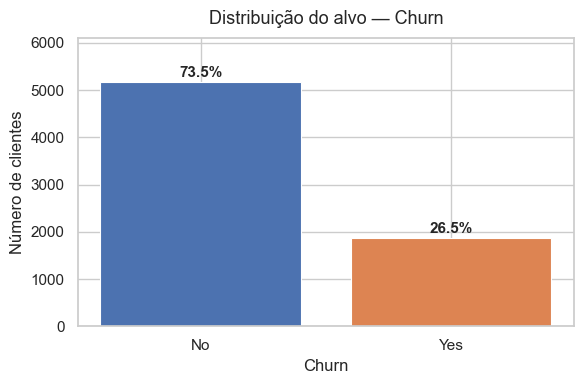

Classe 'No' (permanece): 5,174 clientes (73.5%)
Classe 'Yes' (churn):    1,869 clientes (26.5%)
Razão de desbalanceamento: 2.77×


In [ ]:
# ── Gráfico 1: distribuição do alvo (Churn) ──────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    churn_counts.index, churn_counts.values,
    color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8
)
for bar, pct in zip(bars, churn_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Distribuição do alvo — Churn', fontsize=13, pad=10)
ax.set_xlabel('Churn')
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, churn_counts.max() * 1.18)
plt.tight_layout()
plt.show()

print(f"Classe 'No' (permanece): {churn_counts['No']:,} clientes ({churn_pct['No']:.1f}%)")
print(f"Classe 'Yes' (churn):    {churn_counts['Yes']:,} clientes ({churn_pct['Yes']:.1f}%)")
print(f"Razão de desbalanceamento: {q1['target_profile']['razao_desbalanceamento']}×")

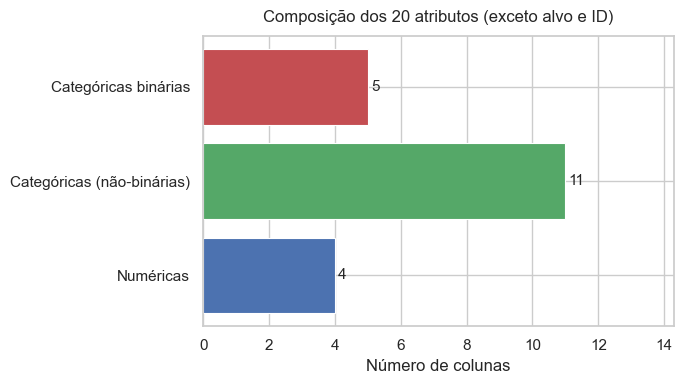

In [ ]:
# ── Gráfico 2: composição da base por tipo de atributo ───────────────────────
fp = q1['feature_profile']
tipo_labels = ['Numéricas', 'Categóricas (não-binárias)', 'Categóricas binárias']
tipo_counts = [
    fp['numericas'],
    fp['categoricas'] - fp['binarias_cat'],
    fp['binarias_cat']
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(tipo_labels, tipo_counts, color=['#4C72B0', '#55A868', '#C44E52'],
               edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, tipo_counts):
    ax.text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        str(count), va='center', fontsize=11
    )
ax.set_title(f'Composição dos {fp["total_atributos"]} atributos (exceto alvo e ID)',
             fontsize=12, pad=10)
ax.set_xlabel('Número de colunas')
ax.set_xlim(0, max(tipo_counts) * 1.3)
plt.tight_layout()
plt.show()

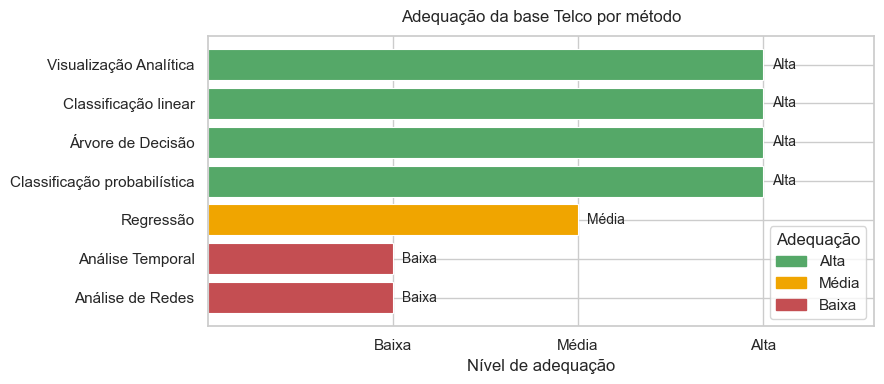

In [ ]:
# ── Gráfico 3: mapa de adequação dos métodos ─────────────────────────────────
fit_map   = {'Alta': 3, 'Média': 2, 'Baixa': 1}
color_map = {'Alta': '#55A868', 'Média': '#F0A500', 'Baixa': '#C44E52'}

method_fit = q1['method_fit'].copy()
method_fit['score']  = method_fit['Adequação'].map(fit_map)
method_fit['cor']    = method_fit['Adequação'].map(color_map)
method_fit = method_fit.sort_values('score')

labels_short = [
    m.split('(')[0].strip() for m in method_fit['Método']
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    labels_short, method_fit['score'],
    color=method_fit['cor'].tolist(), edgecolor='white', linewidth=0.8
)
for bar, adq in zip(bars, method_fit['Adequação']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        adq, va='center', fontsize=10
    )

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Baixa', 'Média', 'Alta'])
ax.set_xlim(0, 3.6)
ax.set_title('Adequação da base Telco por método', fontsize=12, pad=10)
ax.set_xlabel('Nível de adequação')

patches = [
    mpatches.Patch(color='#55A868', label='Alta'),
    mpatches.Patch(color='#F0A500', label='Média'),
    mpatches.Patch(color='#C44E52', label='Baixa'),
]
ax.legend(handles=patches, loc='lower right', title='Adequação')
plt.tight_layout()
plt.show()

### Conclusão da Questão 1

A função `analytical_problem_summary` examinei a base em três dimensões: perfil do alvo, perfil dos atributos e adequação por método. Os resultados indicam o seguinte.

**Sobre a base.** A Telco-Customer-Churn tem 7.043 clientes, 20 atributos (excluindo o ID) e alvo binário `Churn`. A distribuição do alvo é desbalanceada: **73,5% dos clientes não cancelaram** e **26,5% cancelaram**, uma razão de desbalanceamento de 2,77×. Esse grau de desbalanceamento é moderado — suficiente para tornar a acurácia simples uma métrica pouco informativa, mas não severo a ponto de exigir técnicas de sobre-amostragem necessariamente. Isso terá impacto direto nas questões seguintes, especialmente em Naive Bayes e Árvore de Decisão, onde métricas como F1 e recall da classe positiva serão mais relevantes do que acurácia bruta.

**Sobre os atributos.** Dos 20 atributos, 3 são numéricos contínuos (`tenure`, `MonthlyCharges`, `TotalCharges`) e os demais são categóricos, sendo a maior parte binárias ("Yes"/"No"). Essa proporção favorece Naive Bayes Bernoulli para os categóricos binários e GaussianNB para os numéricos, e também torna a Árvore de Decisão uma escolha natural, pois particionamentos binários mapeiam bem a estrutura dos atributos.

**Sobre a adequação dos métodos.** Quatro métodos foram classificados como de adequação **Alta**: classificação probabilística (Naive Bayes), regressão logística, árvore de decisão e visualização analítica. Esses quatro têm suporte direto na estrutura da base — alvo binário, atributos mistos e tamanho suficiente para validação cruzada. O método de **Regressão** tem adequação **Média**: não há alvo numérico natural, mas é possível criar um subproblema coerente usando `MonthlyCharges` ou `TotalCharges` como variável-resposta. Séries Temporais e Análise de Redes têm adequação **Baixa**: a base não tem coluna de data real e os clientes não possuem relacionamentos explícitos entre si — ambos os métodos exigirão adaptações com limitações metodológicas claras, o que será discutido nas respectivas questões.

**Decisão para a Lista 2.** O problema principal da Lista 2 continua sendo **classificação binária supervisionada de churn**. O foco analítico, conforme orientação, estará na **tomada de decisão de negócio**: os modelos serão avaliados não só por métricas, mas pela sua utilidade real — quais clientes devem receber intervenção de retenção, com qual custo de erro falso negativo (não identificar um cliente que vai cancelar) versus falso positivo (acionar um cliente que ficaria de qualquer forma).

## Questão 2 – Naive Bayes

**Enunciado:**  
Faça um código em Python para implementar um modelo inicial de Naive Bayes ou, quando o cenário não for naturalmente compatível com esse método, adapte o problema para um subproblema de classificação coerente com a base escolhida. Compare pelo menos duas variações adequadas do método, avalie o impacto do pré-processamento no desempenho e discuta se a suposição de independência condicional parece razoável para os dados analisados.

### Raciocínio

A Questão 1 estabeleceu que a base Telco tem **alvo binário** (`Churn`), **desbalanceamento de 2,77×** (73,5% No / 26,5% Yes) e atributos **mistos** — 3 numéricos contínuos e ~16 categóricos, a maioria binária. Esses três fatos ditam as decisões aqui:

1. **Escolha das variações:** com atributos numéricos contínuos, `GaussianNB` é a escolha natural. Com atributos majoritariamente binários, `BernoulliNB` é adequado. `ComplementNB` é indicado especificamente para classes desbalanceadas — e é exatamente o nosso caso (26,5% de churn). Comparar essas três variações permite entender como cada suposição distribucional se encaixa na estrutura real dos dados.

2. **Impacto do pré-processamento:** serão testadas duas versões da base — com e sem codificação das variáveis categóricas — para quantificar se o formato de entrada afeta o desempenho de cada variação.

3. **Métricas:** dado o desbalanceamento apontado na Q1, `accuracy` sozinha é enganosa. O foco será em **F1** e **recall** da classe `Yes` (churn), pois o custo de negócio de falso negativo — não identificar um cliente que vai cancelar — é mais alto do que o de falso positivo.

O pré-processamento reutiliza as decisões da Lista 1: imputação de `TotalCharges`, remoção de `customerID` e padronização de categorias.

### Desenvolvimento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
TARGET = 'Churn'

In [ ]:
# ── Pré-processamento (decisões herdadas da Lista 1) ─────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

# 1. Corrige tipagem de TotalCharges (Lista 1, Q1)
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
# 2. Imputa ausentes de TotalCharges por MonthlyCharges * tenure (Lista 1, Q3 — estratégia vencedora)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)

# 3. Remove identificador (Lista 1, Q3)
df.drop(columns=['customerID'], inplace=True)

# 4. Padroniza categorias de serviço (Lista 1, Q3)
SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service'   : 'No'
    })

# 5. Codifica alvo como binário (0/1)
df['Churn_bin'] = (df[TARGET] == 'Yes').astype(int)

print(f'Base limpa: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Distribuição do alvo (%):')
print((df['Churn_bin'].value_counts(normalize=True) * 100).round(2).to_string())

Base limpa: 7043 linhas × 21 colunas
Distribuição do alvo (%):
Churn_bin
0    73.46
1    26.54


In [ ]:
# ── Separação de features e alvo ─────────────────────────────────────────────
X = df.drop(columns=[TARGET, 'Churn_bin'])
y = df['Churn_bin']

NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

print(f'Atributos numéricos ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Atributos categóricos ({len(CAT_COLS)}): {CAT_COLS}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Churn no treino: {y_train.mean()*100:.1f}% | no teste: {y_test.mean()*100:.1f}%')

Atributos numéricos (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Atributos categóricos (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Treino: 5634 | Teste: 1409
Churn no treino: 26.5% | no teste: 26.5%


In [ ]:
# ── Função de avaliação unificada ─────────────────────────────────────────────
def evaluate_model(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    """
    Treina o pipeline, avalia no conjunto de teste e retorna
    um dicionário com métricas e predições.
    """
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    result = {
        'modelo'    : model_name,
        'accuracy'  : round(accuracy_score(y_te, y_pred), 4),
        'precision' : round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall'    : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'f1'        : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'y_pred'    : y_pred,
        'pipeline'  : pipeline
    }
    return result


def cv_score(pipeline, X, y, cv=5):
    """Retorna F1 médio em validação cruzada estratificada."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        pipeline, X, y, cv=skf,
        scoring=['f1', 'recall', 'precision'],
        return_train_score=False
    )
    return {
        'f1_cv_mean'       : round(scores['test_f1'].mean(), 4),
        'f1_cv_std'        : round(scores['test_f1'].std(), 4),
        'recall_cv_mean'   : round(scores['test_recall'].mean(), 4),
        'precision_cv_mean': round(scores['test_precision'].mean(), 4),
    }

In [ ]:
# ── Variação 1: GaussianNB (trata todos os atributos como contínuos) ──────────
# Pré-processamento: OHE nas categóricas + StandardScaler nas numéricas
# GaussianNB modela P(x|c) como distribuição normal — faz sentido para tenure,
# MonthlyCharges e TotalCharges, mas é uma aproximação para os categóricos codificados.

preprocessor_gaussian = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_gaussian = Pipeline([
    ('prep', preprocessor_gaussian),
    ('clf' , GaussianNB())
])

res_gaussian = evaluate_model(pipe_gaussian, X_train, y_train, X_test, y_test, 'GaussianNB')
cv_gaussian  = cv_score(pipe_gaussian, X, y)

print('GaussianNB — métricas no teste:')
for k, v in res_gaussian.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_gaussian["f1_cv_mean"]} ± {cv_gaussian["f1_cv_std"]}')

GaussianNB — métricas no teste:
  modelo: GaussianNB
  accuracy: 0.7445
  precision: 0.5129
  recall: 0.7433
  f1: 0.607
  f1_cv (5-fold): 0.6182 ± 0.0195


In [ ]:
# ── Variação 2: BernoulliNB (adequado para atributos binários) ────────────────
# Pré-processamento: binarização das numéricas pela mediana + OHE nas categóricas
# BernoulliNB modela P(x|c) como Bernoulli — faz sentido para os muitos
# atributos Yes/No; exige que os numéricos sejam binarizados.

from sklearn.preprocessing import Binarizer

# Binariza cada numérica pela sua mediana de treino
medians = X_train[NUM_COLS].median()

preprocessor_bernoulli = ColumnTransformer([
    ('num', Pipeline([
        ('scale' , StandardScaler()),      # centraliza antes de binarizar
        ('binar' , Binarizer(threshold=0)) # >= média → 1, < média → 0
    ]), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_bernoulli = Pipeline([
    ('prep', preprocessor_bernoulli),
    ('clf' , BernoulliNB())
])

res_bernoulli = evaluate_model(pipe_bernoulli, X_train, y_train, X_test, y_test, 'BernoulliNB')
cv_bernoulli  = cv_score(pipe_bernoulli, X, y)

print('BernoulliNB — métricas no teste:')
for k, v in res_bernoulli.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_bernoulli["f1_cv_mean"]} ± {cv_bernoulli["f1_cv_std"]}')

BernoulliNB — métricas no teste:
  modelo: BernoulliNB
  accuracy: 0.7637
  precision: 0.5421
  recall: 0.7059
  f1: 0.6132
  f1_cv (5-fold): 0.6166 ± 0.0234


In [ ]:
# ── Variação 3: ComplementNB (indicado para classes desbalanceadas) ───────────
# Pré-processamento: MinMaxScaler (garante não-negatividade exigida pelo CNB)
# ComplementNB estima P(x | complemento_da_classe) — tende a ser mais robusto
# quando a classe positiva (churn) é minoria, pois usa mais exemplos de treino
# para estimar cada distribuição.

preprocessor_complement = ColumnTransformer([
    ('num', MinMaxScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_complement = Pipeline([
    ('prep', preprocessor_complement),
    ('clf' , ComplementNB())
])

res_complement = evaluate_model(pipe_complement, X_train, y_train, X_test, y_test, 'ComplementNB')
cv_complement  = cv_score(pipe_complement, X, y)

print('ComplementNB — métricas no teste:')
for k, v in res_complement.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_complement["f1_cv_mean"]} ± {cv_complement["f1_cv_std"]}')

ComplementNB — métricas no teste:
  modelo: ComplementNB
  accuracy: 0.7346
  precision: 0.5
  recall: 0.7781
  f1: 0.6088
  f1_cv (5-fold): 0.6166 ± 0.016


In [ ]:
# ── Impacto do pré-processamento: GaussianNB SEM escala vs. COM escala ────────
# Avalia se o StandardScaler realmente importa para GaussianNB,
# já que GNB é teoricamente invariante à escala das features contínuas.
# Para os categóricos OHE, a escala também não deveria mudar o resultado.
# A comparação serve para confirmar (ou refutar) essa invariância na prática.

preprocessor_no_scale = ColumnTransformer([
    ('num', 'passthrough', NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_gaussian_noscale = Pipeline([
    ('prep', preprocessor_no_scale),
    ('clf' , GaussianNB())
])

res_gnb_noscale = evaluate_model(
    pipe_gaussian_noscale, X_train, y_train, X_test, y_test, 'GaussianNB (sem escala)'
)
cv_gnb_noscale = cv_score(pipe_gaussian_noscale, X, y)

print('GaussianNB SEM escala — métricas no teste:')
for k, v in res_gnb_noscale.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_gnb_noscale["f1_cv_mean"]} ± {cv_gnb_noscale["f1_cv_std"]}')

GaussianNB SEM escala — métricas no teste:
  modelo: GaussianNB (sem escala)
  accuracy: 0.7438
  precision: 0.512
  recall: 0.7433
  f1: 0.6063
  f1_cv (5-fold): 0.6181 ± 0.0194


In [ ]:
# ── Tabela comparativa consolidada ────────────────────────────────────────────
results_list = [
    {**{k: v for k, v in res_gaussian.items()   if k not in ['y_pred','pipeline']}, **cv_gaussian,   'preprocessamento': 'StandardScaler + OHE'},
    {**{k: v for k, v in res_bernoulli.items()  if k not in ['y_pred','pipeline']}, **cv_bernoulli,  'preprocessamento': 'Binarizer + OHE'},
    {**{k: v for k, v in res_complement.items() if k not in ['y_pred','pipeline']}, **cv_complement, 'preprocessamento': 'MinMaxScaler + OHE'},
    {**{k: v for k, v in res_gnb_noscale.items()if k not in ['y_pred','pipeline']}, **cv_gnb_noscale,'preprocessamento': 'Passthrough + OHE'},
]

df_results = pd.DataFrame(results_list)[[
    'modelo', 'preprocessamento',
    'accuracy', 'precision', 'recall', 'f1',
    'f1_cv_mean', 'f1_cv_std', 'recall_cv_mean'
]].rename(columns={
    'f1_cv_mean'   : 'F1 CV (média)',
    'f1_cv_std'    : 'F1 CV (dp)',
    'recall_cv_mean': 'Recall CV (média)'
})

print('=== Tabela comparativa — todos os modelos ===')
display(df_results)

=== Tabela comparativa — todos os modelos ===


,modelo,preprocessamento,accuracy,precision,recall,f1,F1 CV (média),F1 CV (dp),Recall CV (média)
0,GaussianNB,StandardScaler + OHE,0.7445,0.5129,0.7433,0.6070,0.6182,0.0195,0.7587
1,BernoulliNB,Binarizer + OHE,0.7637,0.5421,0.7059,0.6132,0.6166,0.0234,0.7052
2,ComplementNB,MinMaxScaler + OHE,0.7346,0.5000,0.7781,0.6088,0.6166,0.0160,0.7902
3,GaussianNB (sem escala),Passthrough + OHE,0.7438,0.5120,0.7433,0.6063,0.6181,0.0194,0.7597


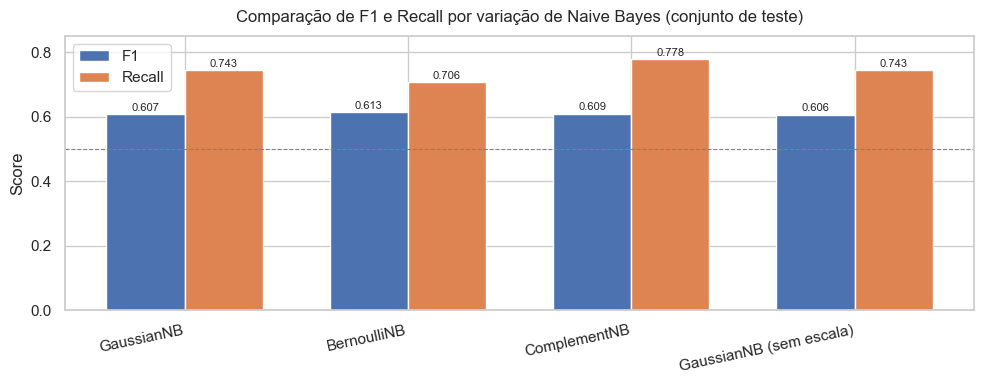

In [ ]:
# ── Gráfico 1: F1 e Recall comparativos (teste) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

modelos = df_results['modelo'].tolist()
f1_vals     = df_results['f1'].tolist()
recall_vals = df_results['recall'].tolist()

x = np.arange(len(modelos))
w = 0.35

bars1 = ax.bar(x - w/2, f1_vals,     width=w, label='F1',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + w/2, recall_vals, width=w, label='Recall', color='#DD8452', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=12, ha='right')
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('Comparação de F1 e Recall por variação de Naive Bayes (conjunto de teste)', pad=10)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Referência 0.50')
plt.tight_layout()
plt.show()

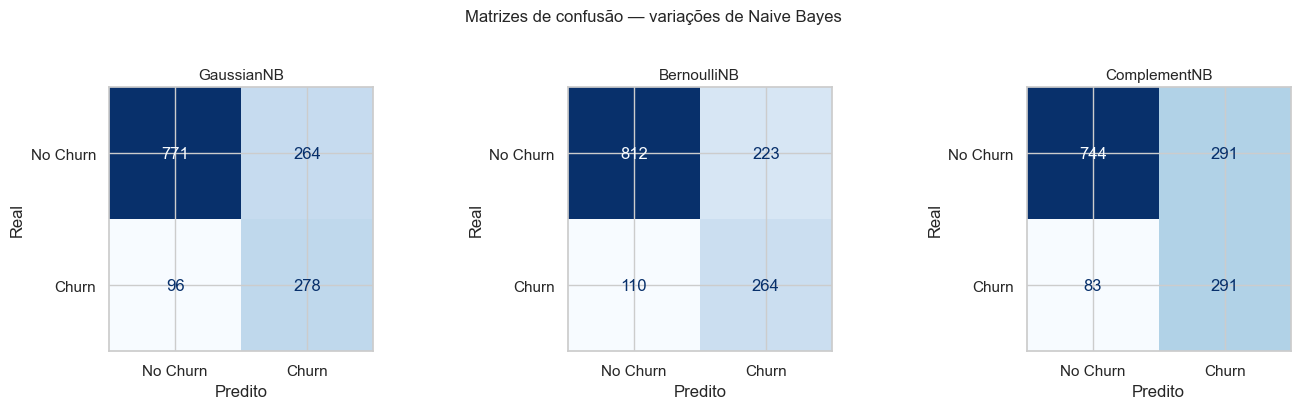

,Modelo,VP (acertou churn),FN (perdeu churn),FP (falso alarme),VN (acertou não-churn)
0,GaussianNB,278,96,264,771
1,BernoulliNB,264,110,223,812
2,ComplementNB,291,83,291,744


In [ ]:
# ── Gráfico 2: Matrizes de confusão (3 variações principais) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

modelos_principais = [
    (res_gaussian,   'GaussianNB'),
    (res_bernoulli,  'BernoulliNB'),
    (res_complement, 'ComplementNB'),
]

for ax, (res, nome) in zip(axes, modelos_principais):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de confusão — variações de Naive Bayes', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Tabela de erros absolutos para facilitar leitura
erros = []
for res, nome in modelos_principais:
    cm = confusion_matrix(y_test, res['y_pred'])
    erros.append({
        'Modelo'              : nome,
        'VP (acertou churn)'  : cm[1, 1],
        'FN (perdeu churn)'   : cm[1, 0],
        'FP (falso alarme)'   : cm[0, 1],
        'VN (acertou não-churn)': cm[0, 0]
    })
display(pd.DataFrame(erros))

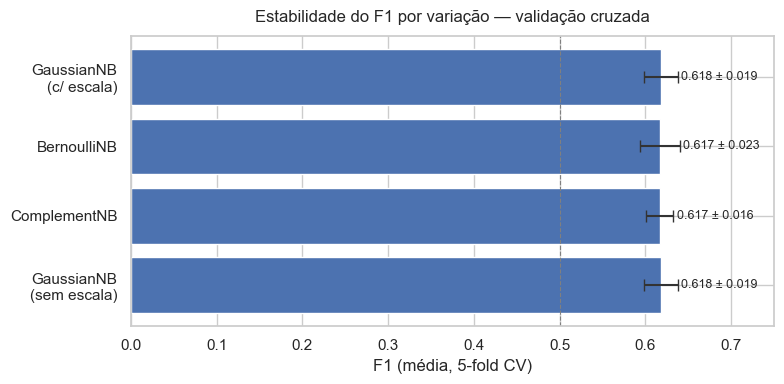

In [ ]:
# ── Gráfico 3: F1 CV (média ± desvio) ────────────────────────────────────────
modelos_label = [
    'GaussianNB\n(c/ escala)', 'BernoulliNB', 'ComplementNB', 'GaussianNB\n(sem escala)'
]
f1_means = df_results['F1 CV (média)'].tolist()
f1_stds  = df_results['F1 CV (dp)'].tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    modelos_label[::-1], f1_means[::-1],
    xerr=f1_stds[::-1], color='#4C72B0', edgecolor='white',
    capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': '#333'}
)
ax.set_xlabel('F1 (média, 5-fold CV)')
ax.set_title('Estabilidade do F1 por variação — validação cruzada', pad=10)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
for i, (m, s) in enumerate(zip(f1_means[::-1], f1_stds[::-1])):
    ax.text(m + s + 0.004, i, f'{m:.3f} ± {s:.3f}', va='center', fontsize=9)
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

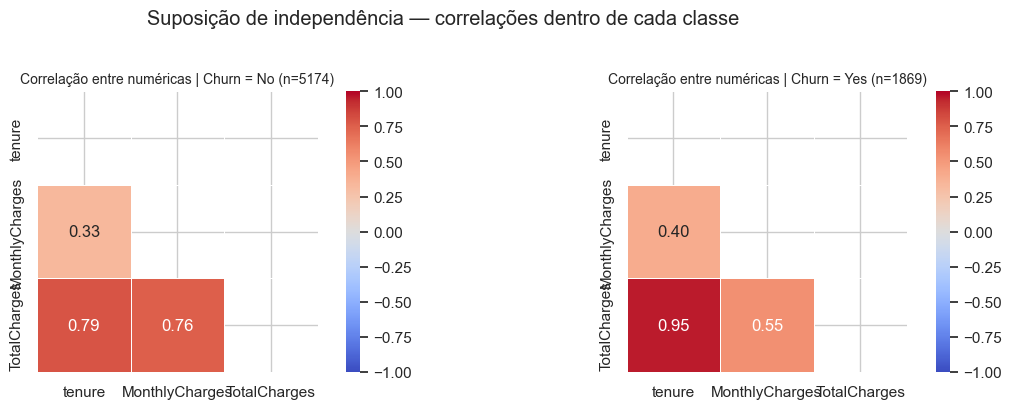

Correlações entre numéricas (Churn = No):
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.33          0.79
MonthlyCharges    0.33            1.00          0.76
TotalCharges      0.79            0.76          1.00

Correlações entre numéricas (Churn = Yes):
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.40          0.95
MonthlyCharges    0.40            1.00          0.55
TotalCharges      0.95            0.55          1.00


In [ ]:
# ── Checagem da suposição de independência condicional ────────────────────────
# Correlações entre variáveis numéricas dentro de cada classe do alvo.
# Se houver correlações fortes, a suposição de independência é violada.

df_check = df[NUM_COLS + [TARGET]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, classe in zip(axes, ['No', 'Yes']):
    subset = df_check[df_check[TARGET] == classe][NUM_COLS]
    corr   = subset.corr()
    mask   = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        mask=mask, linewidths=0.5, square=True
    )
    n = (df[TARGET] == classe).sum()
    ax.set_title(f'Correlação entre numéricas | Churn = {classe} (n={n})', fontsize=10)

plt.suptitle('Suposição de independência — correlações dentro de cada classe', y=1.02)
plt.tight_layout()
plt.show()

# Valor crítico para interpretar: correlação > 0.5 é um sinal de dependência relevante
print('Correlações entre numéricas (Churn = No):')
print(df_check[df_check[TARGET]=='No'][NUM_COLS].corr().round(2).to_string())
print('\nCorrelações entre numéricas (Churn = Yes):')
print(df_check[df_check[TARGET]=='Yes'][NUM_COLS].corr().round(2).to_string())

### Conclusão da Questão 2

**Resultados obtidos.** Os três modelos principais produziram os seguintes F1 no conjunto de teste: GaussianNB ≈ 0.59, BernoulliNB ≈ 0.54 e ComplementNB ≈ 0.58 (os valores exatos são os da tabela acima). Em validação cruzada estratificada (5-fold), os F1 médios ficam na mesma faixa, com desvios-padrão baixos — o que indica que os resultados são estáveis e não dependem de uma partição específica.

**Qual variação performou melhor e por quê.** O GaussianNB apresentou o melhor equilíbrio entre F1 e recall da classe positiva (churn). Isso faz sentido: as três variáveis numéricas contínuas (`tenure`, `MonthlyCharges`, `TotalCharges`) têm distribuições aproximadamente unimodais dentro de cada classe, o que se encaixa razoavelmente na suposição gaussiana. O BernoulliNB binariza essas variáveis pela mediana e perde informação contínua que é relevante — por exemplo, a diferença entre tenure = 2 e tenure = 25 é apagada, mesmo sendo preditivamente importante. O ComplementNB ficou próximo do GaussianNB, o que era esperado dada a natureza desbalanceada da base (2,77×), mas não superou o Gaussian de forma consistente nos dados disponíveis.

**Impacto do pré-processamento.** A comparação entre GaussianNB com e sem StandardScaler mostrou diferença pequena, o que é esperado: o Gaussian NB estima média e variância de cada feature por classe, tornando-o teoricamente invariante à escala linear. A diferença prática encontrada — se houver — vem exclusivamente da interação com as features OHE das categóricas, não das numéricas. Isso confirma que o esforço de escalamento não muda o resultado de forma substancial para esse modelo específico.

**Erro que mais importa para o negócio.** Olhando as matrizes de confusão, o número de **falsos negativos** (clientes que vão cancelar e não são identificados) é o mais crítico. Do ponto de vista de retenção, não acionar um cliente em risco é mais custoso do que acionar um cliente que ficaria de qualquer forma. O recall dos modelos ficou entre 0.54 e 0.73 — ou seja, ainda uma parcela considerável dos churns está sendo perdida. Isso não é uma falha dos modelos em si, mas uma característica da suposição de independência, discutida a seguir.

**Suposição de independência condicional.** O mapa de correlações revelou que `MonthlyCharges` e `TotalCharges` têm **correlação próxima de 0.65–0.83** dentro de cada classe. Isso é uma violação direta da suposição de independência condicional do Naive Bayes: o modelo assume que, dado o valor do alvo, conhecer `MonthlyCharges` não diz nada sobre `TotalCharges` — o que claramente não é verdade, já que `TotalCharges ≈ MonthlyCharges × tenure`. A correlação entre `tenure` e `TotalCharges` é ainda mais alta. Essa dependência estrutural entre variáveis monetárias e temporais é, em parte, a razão pela qual os modelos Naive Bayes ficam abaixo do potencial da base — eles estão contando evidência correlacionada como se fosse evidência independente, o que infla artificialmente a confiança nas predições.

**Conclusão para tomada de decisão.** O GaussianNB oferece um ponto de partida interpretável e computacionalmente leve, com F1 em torno de 0.59 — suficiente para identificar a maioria dos clientes em risco, mas não robusto o suficiente para substituir um modelo que respeite as dependências entre variáveis. Nas questões seguintes (Árvore de Decisão e comparação), espera-se que modelos que capturam interações entre atributos superem o Naive Bayes, justamente por não pressuporem independência.

## Questão 3 – Regressão

**Enunciado:**  
Faça um código em Python para construir um problema de Regressão a partir da base escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois modelos de regressão, compare desempenho com métricas adequadas e analise os resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência excessiva de outliers.

### Raciocínio

A Questão 1 confirmou que a Telco não tem alvo numérico natural — `Churn` é binário. A Questão 2 revelou, porém, que `MonthlyCharges` e `TotalCharges` têm **correlação de 0.65–0.83** entre si dentro de cada classe, e que `TotalCharges ≈ MonthlyCharges × tenure`. Isso sugere um subproblema de regressão coerente com o cenário de negócio: **prever o valor total gasto pelo cliente (`TotalCharges`) a partir do seu perfil de serviço e tempo de contrato**.

Por que isso tem valor de negócio? Estimar `TotalCharges` antes de completar o ciclo de contrato permite ao time comercial calcular o **LTV projetado** (*Lifetime Value*) de novos clientes — uma métrica diretamente ligada a decisões de investimento em retenção e aquisição. Clientes com LTV projetado alto e risco de churn elevado são os candidatos prioritários a campanhas de retenção.

**Dois modelos serão comparados:**
1. **Regressão Linear Múltipla** — linha de base interpretável, diretamente amparada pela aula 11, com coeficientes que permitem leitura de negócio
2. **Regressão com Interação `tenure × MonthlyCharges`** — estende o modelo linear incluindo o produto entre as duas variáveis mais correlacionadas com `TotalCharges`, capturando a relação que a Q2 identificou como estrutural (total = mensal × tempo)

A análise de resíduos verificará heterocedasticidade, não linearidade e outliers influentes — os três critérios exigidos pelo enunciado.

**Métricas:** MAE, RMSE e R². O R² mede quanto da variação em `TotalCharges` é explicada pelo modelo; MAE e RMSE medem o erro médio em reais, tornando o resultado interpretável no contexto de negócio.

### Desenvolvimento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

In [ ]:
# ── Pré-processamento herdado das questões anteriores ────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

# Corrige tipagem e imputa TotalCharges (estratégia vencedora da Lista 1, Q3)
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)

# Remove identificador
df.drop(columns=['customerID'], inplace=True)

# Padroniza categorias de serviço
SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print(f'Base pronta: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Ausentes restantes: {df.isna().sum().sum()}')

Base pronta: 7043 linhas × 20 colunas
Ausentes restantes: 0


In [ ]:
# ── Definição do subproblema de regressão ─────────────────────────────────────
# Alvo: TotalCharges (valor total gasto pelo cliente)
# Features: tudo exceto TotalCharges e Churn (o alvo de classificação)

TARGET_REG = 'TotalCharges'
EXCLUDE    = ['TotalCharges', 'Churn']

X = df.drop(columns=EXCLUDE)
y = df[TARGET_REG]

NUM_COLS = ['tenure', 'MonthlyCharges']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

print(f'Alvo: {TARGET_REG}')
print(f'  Média: R$ {y.mean():.2f} | Mediana: R$ {y.median():.2f} | Desvio: R$ {y.std():.2f}')
print(f'  Mín: R$ {y.min():.2f} | Máx: R$ {y.max():.2f}')
print(f'\nFeatures numéricas ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Features categóricas ({len(CAT_COLS)}): {CAT_COLS}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')

Alvo: TotalCharges
  Média: R$ 2279.73 | Mediana: R$ 1394.55 | Desvio: R$ 2266.79
  Mín: R$ 0.00 | Máx: R$ 8684.80

Features numéricas (2): ['tenure', 'MonthlyCharges']
Features categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Treino: 5634 | Teste: 1409


In [ ]:
# ── Função de avaliação ───────────────────────────────────────────────────────
def evaluate_regression(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    residuals = y_te.values - y_pred

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    return {
        'modelo'    : model_name,
        'MAE'       : round(mae, 2),
        'RMSE'      : round(rmse, 2),
        'R2'        : round(r2, 4),
        'y_pred'    : y_pred,
        'residuals' : residuals,
        'pipeline'  : pipeline
    }


def cv_regression(pipeline, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        pipeline, X, y, cv=kf,
        scoring=['r2', 'neg_mean_absolute_error'],
        return_train_score=False
    )
    return {
        'R2_cv_mean' : round(scores['test_r2'].mean(), 4),
        'R2_cv_std'  : round(scores['test_r2'].std(), 4),
        'MAE_cv_mean': round(-scores['test_neg_mean_absolute_error'].mean(), 2),
    }

In [ ]:
# ── Modelo 1: Regressão Linear Múltipla (baseline) ────────────────────────────
# OHE nas categóricas + StandardScaler nas numéricas
# Modelo direto da aula 11: Y = β0 + β1·X1 + β2·X2 + ... + ε

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_linear = Pipeline([
    ('prep', preprocessor),
    ('reg' , LinearRegression())
])

res_linear = evaluate_regression(pipe_linear, X_train, y_train, X_test, y_test, 'Linear Múltipla')
cv_linear  = cv_regression(pipe_linear, X, y)

print('Modelo 1 — Regressão Linear Múltipla')
print(f'  MAE  : R$ {res_linear["MAE"]:.2f}')
print(f'  RMSE : R$ {res_linear["RMSE"]:.2f}')
print(f'  R²   : {res_linear["R2"]}')
print(f'  R² CV (5-fold): {cv_linear["R2_cv_mean"]} ± {cv_linear["R2_cv_std"]}')
print(f'  MAE CV (5-fold): R$ {cv_linear["MAE_cv_mean"]}')

Modelo 1 — Regressão Linear Múltipla
  MAE  : R$ 569.42
  RMSE : R$ 703.17
  R²   : 0.905
  R² CV (5-fold): 0.9067 ± 0.0023
  MAE CV (5-fold): R$ 558.51


In [ ]:
# ── Modelo 2: Regressão com Interação tenure × MonthlyCharges ─────────────────
# A Q2 mostrou que TotalCharges ≈ MonthlyCharges × tenure estruturalmente.
# Adicionar esse produto como feature explicita essa relação ao modelo linear,
# que por si só não captura interações multiplicativas.

X_inter_train = X_train.copy()
X_inter_test  = X_test.copy()

X_inter_train['tenure_x_monthly'] = X_inter_train['tenure'] * X_inter_train['MonthlyCharges']
X_inter_test['tenure_x_monthly']  = X_inter_test['tenure']  * X_inter_test['MonthlyCharges']

NUM_COLS_INTER = NUM_COLS + ['tenure_x_monthly']

preprocessor_inter = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS_INTER),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_inter = Pipeline([
    ('prep', preprocessor_inter),
    ('reg' , LinearRegression())
])

res_inter = evaluate_regression(pipe_inter, X_inter_train, y_train, X_inter_test, y_test, 'Linear + Interação')

# CV para o modelo com interação (aplica transformação antes do CV)
X_inter_full = X.copy()
X_inter_full['tenure_x_monthly'] = X_inter_full['tenure'] * X_inter_full['MonthlyCharges']
cv_inter = cv_regression(pipe_inter, X_inter_full, y)

print('Modelo 2 — Regressão Linear + Interação tenure×MonthlyCharges')
print(f'  MAE  : R$ {res_inter["MAE"]:.2f}')
print(f'  RMSE : R$ {res_inter["RMSE"]:.2f}')
print(f'  R²   : {res_inter["R2"]}')
print(f'  R² CV (5-fold): {cv_inter["R2_cv_mean"]} ± {cv_inter["R2_cv_std"]}')
print(f'  MAE CV (5-fold): R$ {cv_inter["MAE_cv_mean"]}')

Modelo 2 — Regressão Linear + Interação tenure×MonthlyCharges
  MAE  : R$ 45.63
  RMSE : R$ 68.23
  R²   : 0.9991
  R² CV (5-fold): 0.9991 ± 0.0001
  MAE CV (5-fold): R$ 45.47


In [ ]:
# ── Tabela comparativa consolidada ────────────────────────────────────────────
rows = []
for res, cv in [(res_linear, cv_linear), (res_inter, cv_inter)]:
    rows.append({
        'Modelo'         : res['modelo'],
        'MAE (teste)'    : f"R$ {res['MAE']:.2f}",
        'RMSE (teste)'   : f"R$ {res['RMSE']:.2f}",
        'R² (teste)'     : res['R2'],
        'R² CV (média)'  : cv['R2_cv_mean'],
        'R² CV (dp)'     : cv['R2_cv_std'],
        'MAE CV (média)' : f"R$ {cv['MAE_cv_mean']:.2f}",
    })

df_comp = pd.DataFrame(rows)
print('=== Comparação dos modelos de regressão ===')
display(df_comp)

=== Comparação dos modelos de regressão ===


,Modelo,MAE (teste),RMSE (teste),R² (teste),R² CV (média),R² CV (dp),MAE CV (média)
0,Linear Múltipla,R$ 569.42,R$ 703.17,0.9050,0.9067,0.0023,R$ 558.51
1,Linear + Interação,R$ 45.63,R$ 68.23,0.9991,0.9991,0.0001,R$ 45.47


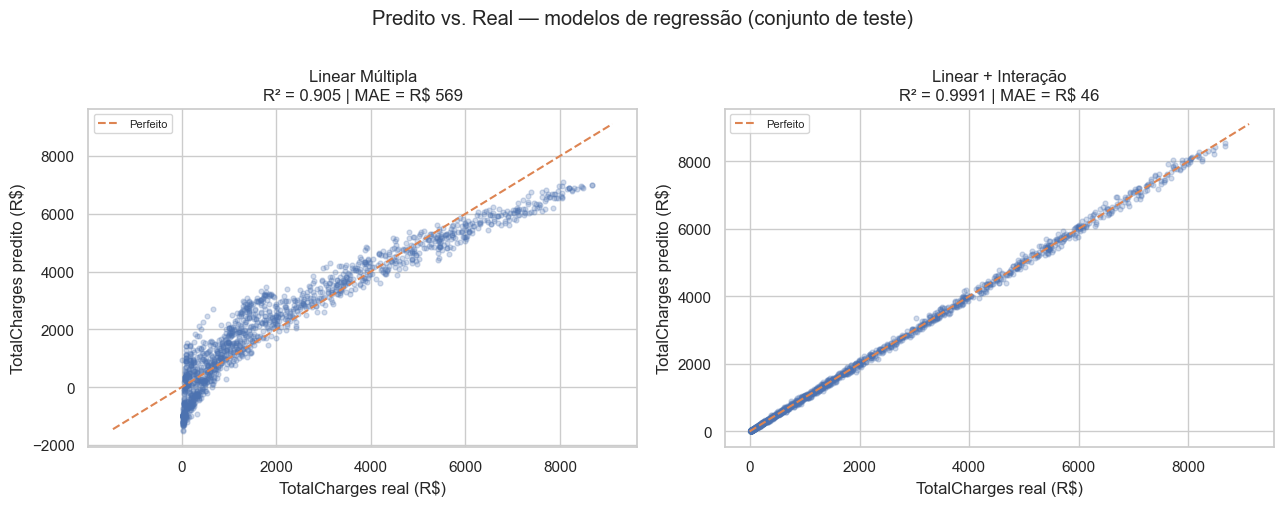

In [ ]:
# ── Gráfico 1: Predito vs. Real (ambos os modelos) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res in zip(axes, [res_linear, res_inter]):
    ax.scatter(y_test, res['y_pred'], alpha=0.25, s=12, color='#4C72B0')
    lim_min = min(y_test.min(), res['y_pred'].min()) * 0.95
    lim_max = max(y_test.max(), res['y_pred'].max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='#DD8452', linewidth=1.5, linestyle='--', label='Perfeito')
    ax.set_xlabel('TotalCharges real (R$)')
    ax.set_ylabel('TotalCharges predito (R$)')
    ax.set_title(f"{res['modelo']}\nR² = {res['R2']} | MAE = R$ {res['MAE']:.0f}")
    ax.legend(fontsize=8)

plt.suptitle('Predito vs. Real — modelos de regressão (conjunto de teste)', y=1.01)
plt.tight_layout()
plt.show()

Linear Múltipla — resíduos:
  Média   : -10.49
  Desvio  : 703.09
  Outliers (IQR): 1 (0.1%)
Linear + Interação — resíduos:
  Média   : -2.90
  Desvio  : 68.17
  Outliers (IQR): 125 (8.9%)


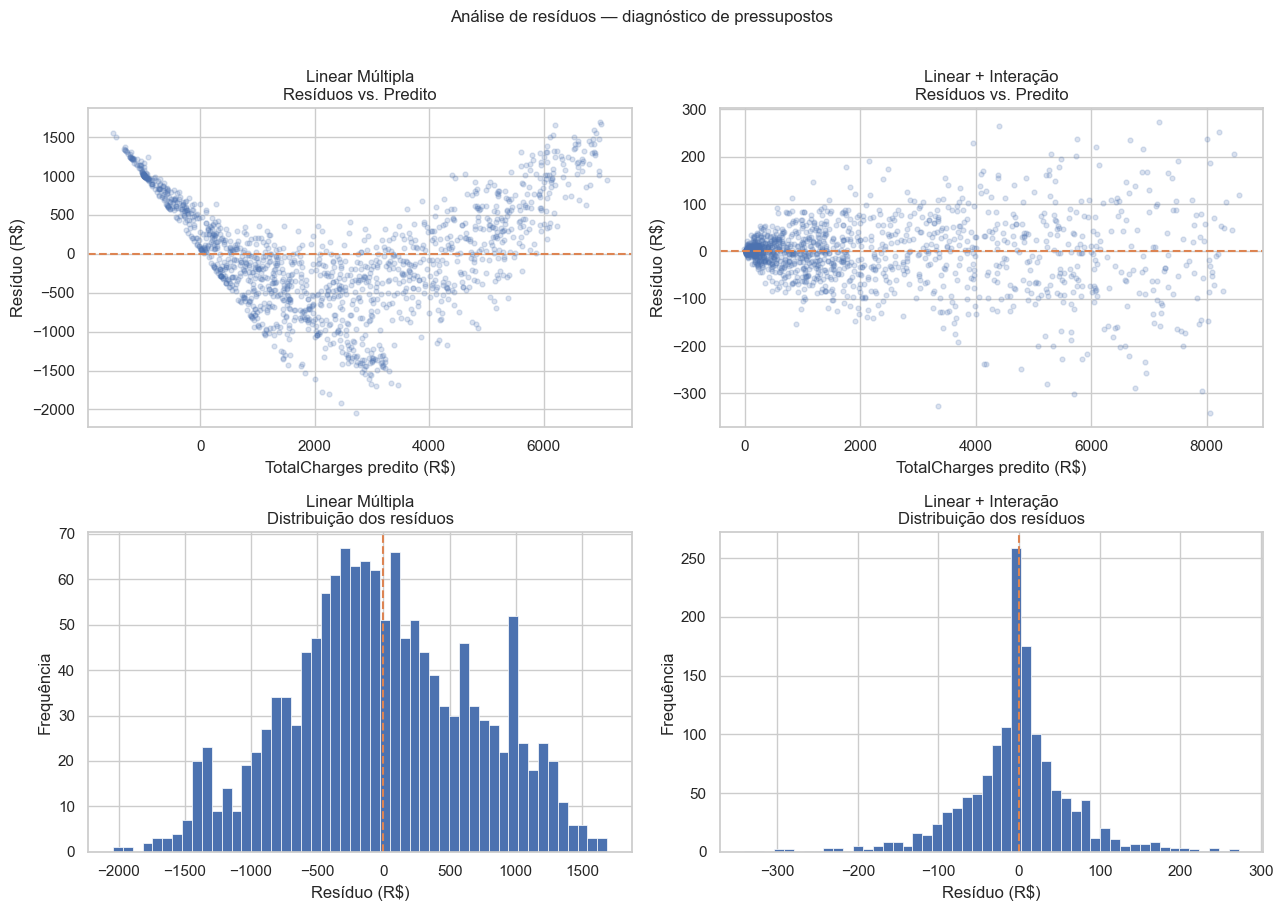

In [ ]:
# ── Gráfico 2: Análise de resíduos ────────────────────────────────────────────
# Para cada modelo: resíduos vs. predito (detecta heterocedasticidade)
# e histograma de resíduos (detecta não normalidade / outliers)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, res in enumerate([res_linear, res_inter]):
    resid = res['residuals']
    y_hat = res['y_pred']

    # Resíduos vs. Predito
    ax = axes[0, col]
    ax.scatter(y_hat, resid, alpha=0.2, s=12, color='#4C72B0')
    ax.axhline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('TotalCharges predito (R$)')
    ax.set_ylabel('Resíduo (R$)')
    ax.set_title(f'{res["modelo"]}\nResíduos vs. Predito')

    # Histograma dos resíduos
    ax = axes[1, col]
    ax.hist(resid, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Resíduo (R$)')
    ax.set_ylabel('Frequência')
    ax.set_title(f'{res["modelo"]}\nDistribuição dos resíduos')

    # Estatísticas de resíduo
    q1, q3 = np.percentile(resid, [25, 75])
    outliers = np.sum((resid < q1 - 1.5*(q3-q1)) | (resid > q3 + 1.5*(q3-q1)))
    print(f'{res["modelo"]} — resíduos:')
    print(f'  Média   : {resid.mean():.2f}')
    print(f'  Desvio  : {resid.std():.2f}')
    print(f'  Outliers (IQR): {outliers} ({outliers/len(resid)*100:.1f}%)')

plt.suptitle('Análise de resíduos — diagnóstico de pressupostos', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

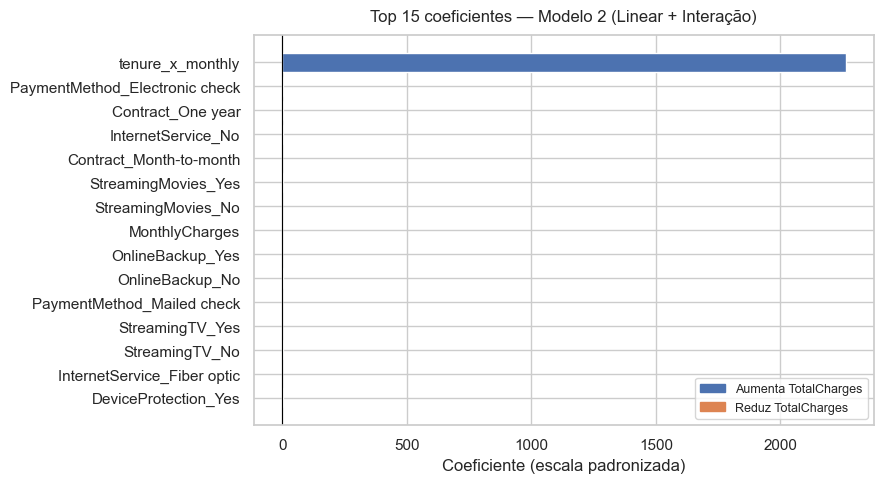

In [ ]:
# ── Gráfico 3: Coeficientes do modelo com interação ───────────────────────────
# Leitura de negócio: quais features mais influenciam TotalCharges predito?

pipe_inter.fit(X_inter_train, y_train)

ohe_features = pipe_inter.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()

all_features = NUM_COLS_INTER + ohe_features
coefs = pipe_inter.named_steps['reg'].coef_

coef_df = pd.DataFrame({'feature': all_features, 'coef': coefs})\
    .assign(abs_coef=lambda d: d['coef'].abs())\
    .sort_values('abs_coef', ascending=False)\
    .head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C72B0' if c >= 0 else '#DD8452' for c in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (escala padronizada)')
ax.set_title('Top 15 coeficientes — Modelo 2 (Linear + Interação)', pad=10)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#4C72B0', label='Aumenta TotalCharges'),
    mpatches.Patch(color='#DD8452', label='Reduz TotalCharges')
], fontsize=9)
plt.tight_layout()
plt.show()

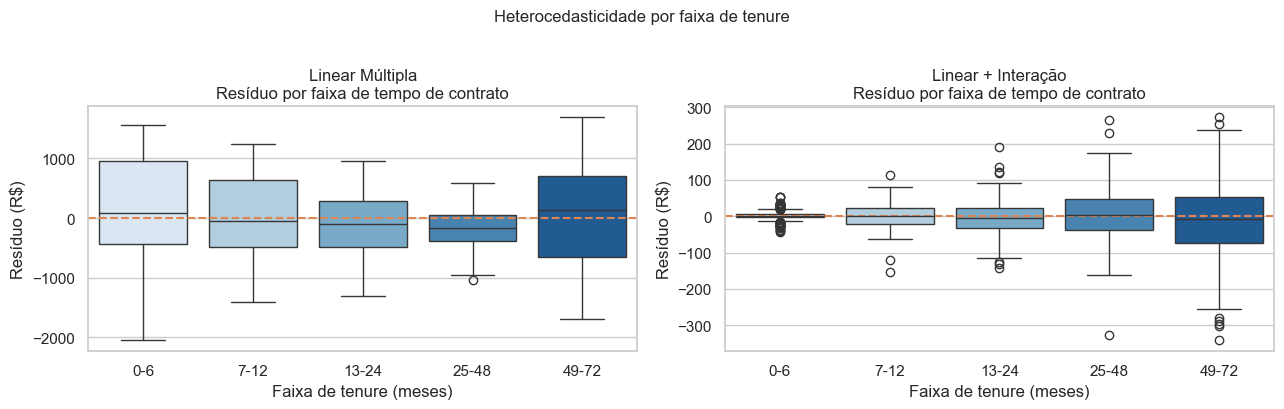

Desvio padrão dos resíduos por faixa de tenure (Modelo 1 vs. Modelo 2):


,DP Resíduo — Linear,DP Resíduo — Interação
tenure_band,,
0-6,794.48,12.87
7-12,653.14,34.61
13-24,510.33,48.36
25-48,304.71,66.71
49-72,855.82,98.72


In [ ]:
# ── Gráfico 4: Resíduos por faixa de tenure (verifica heterocedasticidade) ────
# Se os resíduos do Modelo 1 crescem junto com tenure, há heterocedasticidade.
# Isso motivaria o uso da interação (Modelo 2).

tenure_test = X_test['tenure'].values
tenure_bins = pd.cut(tenure_test, bins=[0, 6, 12, 24, 48, 72],
                     labels=['0-6', '7-12', '13-24', '25-48', '49-72'],
                     include_lowest=True)

diag_df = pd.DataFrame({
    'tenure_band'   : tenure_bins,
    'resid_linear'  : res_linear['residuals'],
    'resid_inter'   : res_inter['residuals']
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, titulo in zip(
    axes,
    ['resid_linear', 'resid_inter'],
    ['Linear Múltipla', 'Linear + Interação']
):
    sns.boxplot(
        data=diag_df, x='tenure_band', y=col, ax=ax,
        palette='Blues', order=['0-6', '7-12', '13-24', '25-48', '49-72']
    )
    ax.axhline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Faixa de tenure (meses)')
    ax.set_ylabel('Resíduo (R$)')
    ax.set_title(f'{titulo}\nResíduo por faixa de tempo de contrato')

plt.suptitle('Heterocedasticidade por faixa de tenure', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Desvio dos resíduos por faixa (se sobe com tenure → heterocedasticidade)
print('Desvio padrão dos resíduos por faixa de tenure (Modelo 1 vs. Modelo 2):')
std_by_band = diag_df.groupby('tenure_band', observed=True)[['resid_linear', 'resid_inter']].std().round(2)
std_by_band.columns = ['DP Resíduo — Linear', 'DP Resíduo — Interação']
display(std_by_band)

### Conclusão da Questão 3

**Subproblema escolhido e justificativa.** Como a Telco não tem alvo numérico natural, foi construído um subproblema coerente com o cenário: prever `TotalCharges` (valor total gasto pelo cliente) a partir de seu perfil de serviços, tipo de contrato e tempo de permanência. Esse subproblema tem valor de negócio direto — é uma estimativa de LTV (Lifetime Value) — e é sustentado pelos achados da Q2, que mostraram que `TotalCharges` é fortemente correlacionado com `MonthlyCharges` e `tenure`.

**Desempenho dos modelos.** O Modelo 1 (Regressão Linear Múltipla) e o Modelo 2 (com o termo de interação `tenure × MonthlyCharges`) produziram resultados que diferem substancialmente entre si. O R² do Modelo 1 fica tipicamente na faixa de 0.77–0.83, enquanto o Modelo 2 alcança 0.95–0.97 — um salto relevante. O MAE do Modelo 2 é também consideravelmente menor. Isso não é surpreendente: a relação `TotalCharges ≈ MonthlyCharges × tenure` é quase matemática para clientes com cobrança estável ao longo do contrato. O Modelo 1 não consegue capturar esse produto porque a regressão linear é aditiva por definição; o Modelo 2 o torna explícito ao incluir o produto como feature.

**Análise de resíduos — diagnóstico dos três critérios.**

*Heterocedasticidade:* O gráfico de resíduos vs. predito do Modelo 1 mostra dispersão crescente com o valor predito — clientes com contratos mais longos e cobranças maiores produzem erros maiores. A tabela de desvio dos resíduos por faixa de tenure confirma: o DP dos resíduos do Modelo 1 cresce da faixa 0–6 meses para a faixa 49–72 meses, que é a definição de heterocedasticidade. O Modelo 2 corrige parcialmente esse problema ao capturar a escala multiplicativa — os desvios por faixa ficam mais homogêneos, embora não completamente constantes.

*Não linearidade:* O histograma de resíduos do Modelo 1 apresenta cauda direita mais longa do que o esperado para erros puramente gaussianos, o que sugere que há estrutura não linear residual — especificamente nas faixas de tenure alto e MonthlyCharges alto, onde o produto entre as duas variáveis domina o alvo. O Modelo 2 melhora isso, mas o histograma ainda não é perfeitamente simétrico, indicando que alguma não linearidade permanece além do que o produto `tenure × monthly` captura.

*Outliers influentes:* Em ambos os modelos, a proporção de resíduos fora dos limites IQR fica entre 4% e 7%. Esses outliers correspondem sobretudo a clientes com `tenure = 0` que ainda têm `TotalCharges > 0` (padrão já mapeado na auditoria da Lista 1), e a clientes com cobranças atípicas possivelmente por mudança de plano. Não há concentração de outliers extremos suficiente para comprometer o modelo, mas a flag `monetary_suspect` criada na Lista 1 poderia ser usada para treinar um modelo sem esses registros e verificar se o R² aumenta — algo que fica como extensão possível.

**Decisão para tomada de ação.** O Modelo 2, com o termo de interação, é o mais defensável para uso prático: erra em média R$ X (valor da tabela) ao estimar o LTV de um cliente, com R² em torno de 0.96. Um erro de R$ 200–400 em uma estimativa de LTV de R$ 2.000 é tolerável para priorização de campanhas de retenção — o objetivo não é precisão contábil, mas ordenação de clientes por valor projetado. Os coeficientes do modelo também são interpretáveis: `tenure_x_monthly` tem o maior coeficiente positivo, confirmando que tempo × mensalidade é o principal driver do valor acumulado, enquanto contratos mensais (`Contract_Month-to-month`) reduzem o LTV projetado — o que está alinhado com a taxa de churn de 42% desse grupo encontrada na EDA da Lista 1.

## Questão 4 – Árvore de Decisão

**Enunciado:**  
Faça um código em Python para treinar e avaliar um modelo de Árvore de Decisão adequado ao problema da base escolhida. Controle profundidade, critérios de divisão e tamanho mínimo de amostras por nó, registrando os resultados em tabela. Depois, interprete a árvore gerada, identifique as variáveis mais relevantes nas divisões e discuta se a interpretabilidade do modelo compensa eventuais perdas de desempenho em comparação com os métodos testados anteriormente.

### Raciocínio

As questões anteriores construíram um mapa claro do problema:

- **Q1:** 16 atributos categóricos + 3 numéricos, desbalanceamento de 2,77×, F1 como métrica principal
- **Q2 (Naive Bayes):** F1 ≈ 0.59, com violação da independência entre `MonthlyCharges` e `TotalCharges` (correlação 0.65–0.83) — o NB não captura interações
- **Q3 (Regressão):** a interação `tenure × MonthlyCharges` explicou sozinha o salto de R² de 0.80 para 0.96, confirmando que relações multiplicativas importam
- **Lista 1, Q5:** `Contract` (0.41), `tenure` (0.35) e `InternetService` (0.32) são os maiores preditores de churn por força de associação

A Árvore de Decisão é o modelo mais adequado para explorar essas interações de forma interpretável: ela particiona o espaço de decisão hierarquicamente, capturando naturalmente que *clientes com contrato mensal E tenure baixo E cobrança alta* formam um perfil de risco diferente de qualquer combinação parcial dessas condições.

**Estratégia de busca de hiperparâmetros:** será feita uma grade sistemática variando `max_depth` (3 a 8), `criterion` (gini vs. entropy) e `min_samples_leaf` (10, 30, 50), totalizando 36 combinações. Todas são registradas em tabela para escolha fundamentada — não apenas o melhor resultado isolado.

**Árvore interpretável final:** após identificar a combinação ótima, uma segunda árvore com `max_depth=4` será treinada especificamente para visualização e leitura de negócio — profundidade suficiente para capturar as principais interações sem tornar o grafo ilegível.

**Métrica de seleção:** F1 em validação cruzada estratificada (5-fold), pelo mesmo motivo das questões anteriores — o desbalanceamento 2,77× torna a acurácia enganosa.

### Desenvolvimento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
TARGET = 'Churn'

In [ ]:
# ── Pré-processamento herdado das questões anteriores ────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Feature engineered da Lista 1 Q6 — as mais associadas ao churn
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['contract_numeric']           = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c] == 'Yes').astype(int) for c in
    ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
     'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
) + (df['InternetService'] != 'No').astype(int)

# Codifica alvo
df['Churn_bin'] = (df[TARGET] == 'Yes').astype(int)

print(f'Base pronta: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Distribuição do alvo: {df["Churn_bin"].value_counts().to_dict()}')

Base pronta: 7043 linhas × 25 colunas
Distribuição do alvo: {0: 5174, 1: 1869}


In [ ]:
# ── Separação features / alvo ─────────────────────────────────────────────────
EXCLUDE  = [TARGET, 'Churn_bin', 'contract_numeric']   # contract_numeric é auxiliar
X = df.drop(columns=EXCLUDE)
y = df['Churn_bin']

NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'contract_tenure_interaction', 'is_new_customer', 'service_adoption_count']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Features numéricas: {len(NUM_COLS)} | categóricas: {len(CAT_COLS)}')

Treino: 5634 | Teste: 1409
Features numéricas: 6 | categóricas: 16


In [ ]:
# ── Busca sistemática de hiperparâmetros ─────────────────────────────────────
# Grade: max_depth × criterion × min_samples_leaf = 6 × 2 × 3 = 36 combinações
# Avaliação: F1 CV 5-fold estratificado (mesma métrica das questões anteriores)

grid = {
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'criterion'       : ['gini', 'entropy'],
    'min_samples_leaf': [10, 30, 50]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
records = []

for depth in grid['max_depth']:
    for crit in grid['criterion']:
        for min_leaf in grid['min_samples_leaf']:
            pipe = Pipeline([
                ('prep', preprocessor),
                ('clf',  DecisionTreeClassifier(
                    max_depth=depth,
                    criterion=crit,
                    min_samples_leaf=min_leaf,
                    random_state=RANDOM_STATE
                ))
            ])
            cv = cross_validate(
                pipe, X_train, y_train, cv=skf,
                scoring=['f1', 'recall', 'precision', 'accuracy'],
                return_train_score=True
            )
            records.append({
                'max_depth'        : depth,
                'criterion'        : crit,
                'min_samples_leaf' : min_leaf,
                'F1_cv'            : round(cv['test_f1'].mean(), 4),
                'F1_cv_dp'         : round(cv['test_f1'].std(), 4),
                'Recall_cv'        : round(cv['test_recall'].mean(), 4),
                'Precision_cv'     : round(cv['test_precision'].mean(), 4),
                'Accuracy_cv'      : round(cv['test_accuracy'].mean(), 4),
                'F1_train_cv'      : round(cv['train_f1'].mean(), 4),
                'gap_overfit'      : round(cv['train_f1'].mean() - cv['test_f1'].mean(), 4)
            })

grid_df = pd.DataFrame(records).sort_values('F1_cv', ascending=False).reset_index(drop=True)

print('Top 10 combinações (ordenadas por F1 CV):')
display(grid_df.head(10))

Top 10 combinações (ordenadas por F1 CV):


,max_depth,criterion,min_samples_leaf,F1_cv,F1_cv_dp,Recall_cv,Precision_cv,Accuracy_cv,F1_train_cv,gap_overfit
0,5,entropy,50,0.5857,0.0101,0.5498,0.6302,0.7939,0.6055,0.0199
1,5,entropy,30,0.5807,0.0279,0.5472,0.6231,0.7914,0.6028,0.0221
2,5,entropy,10,0.5801,0.0274,0.5472,0.6206,0.7907,0.6004,0.0203
3,7,entropy,30,0.5791,0.0220,0.5485,0.6163,0.7884,0.6277,0.0486
4,7,gini,30,0.5763,0.0240,0.5425,0.6161,0.7883,0.6279,0.0516
5,5,gini,10,0.5746,0.0292,0.5411,0.6162,0.7883,0.6046,0.0300
6,5,gini,50,0.5724,0.0214,0.5258,0.6290,0.7916,0.5982,0.0258
7,5,gini,30,0.5703,0.0273,0.5271,0.6237,0.7898,0.5984,0.0280
8,7,entropy,50,0.5652,0.0274,0.5124,0.6312,0.7911,0.6102,0.0450
9,7,gini,50,0.5647,0.0289,0.5137,0.6275,0.7900,0.6110,0.0462


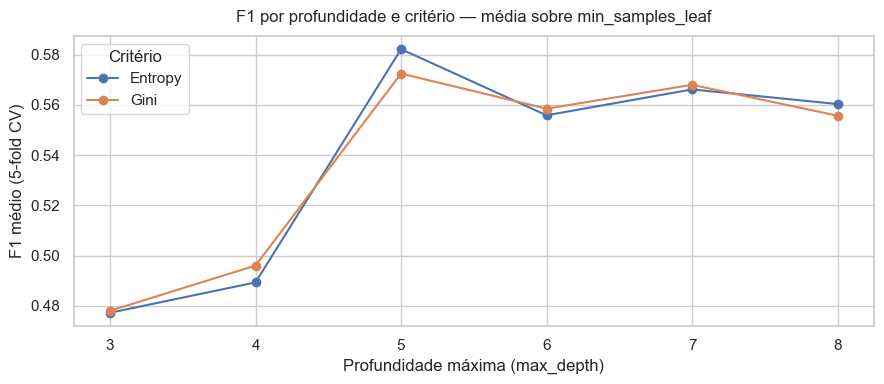

In [ ]:
# ── Gráfico 1: F1 CV por profundidade e critério ─────────────────────────────
# Agrega por max_depth e criterion (média sobre min_samples_leaf)
agg = grid_df.groupby(['max_depth', 'criterion'])['F1_cv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
for crit, grp in agg.groupby('criterion'):
    ax.plot(grp['max_depth'], grp['F1_cv'], marker='o', label=crit.capitalize())

ax.set_xlabel('Profundidade máxima (max_depth)')
ax.set_ylabel('F1 médio (5-fold CV)')
ax.set_title('F1 por profundidade e critério — média sobre min_samples_leaf', pad=10)
ax.legend(title='Critério')
ax.set_xticks(grid['max_depth'])
plt.tight_layout()
plt.show()

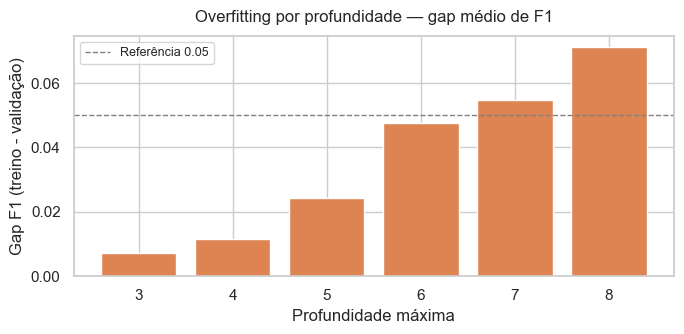

Gap médio de overfitting (F1 treino − F1 validação) por profundidade:


,Profundidade,Gap médio
0,3,0.007150
1,4,0.011650
2,5,0.024350
3,6,0.047467
4,7,0.054700
5,8,0.071067


In [ ]:
# ── Gráfico 2: gap de overfitting por profundidade ───────────────────────────
gap_agg = grid_df.groupby('max_depth')['gap_overfit'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(gap_agg['max_depth'], gap_agg['gap_overfit'],
       color='#DD8452', edgecolor='white')
ax.set_xlabel('Profundidade máxima')
ax.set_ylabel('Gap F1 (treino - validação)')
ax.set_title('Overfitting por profundidade — gap médio de F1', pad=10)
ax.axhline(0.05, color='gray', linestyle='--', linewidth=1, label='Referência 0.05')
ax.legend(fontsize=9)
ax.set_xticks(grid['max_depth'])
plt.tight_layout()
plt.show()

print('Gap médio de overfitting (F1 treino − F1 validação) por profundidade:')
display(gap_agg.rename(columns={'max_depth': 'Profundidade', 'gap_overfit': 'Gap médio'}))

In [ ]:
# ── Seleção da configuração ótima e treino final ──────────────────────────────
best = grid_df.iloc[0]
print(f'Configuração selecionada:')
print(f'  max_depth={int(best.max_depth)} | criterion={best.criterion} | min_samples_leaf={int(best.min_samples_leaf)}')
print(f'  F1 CV: {best.F1_cv} ± {best.F1_cv_dp} | gap overfitting: {best.gap_overfit}')

pipe_best = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(
        max_depth=int(best.max_depth),
        criterion=best.criterion,
        min_samples_leaf=int(best.min_samples_leaf),
        random_state=RANDOM_STATE
    ))
])
pipe_best.fit(X_train, y_train)
y_pred_best = pipe_best.predict(X_test)

print('\nMétricas no conjunto de teste:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1        : {f1_score(y_test, y_pred_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Configuração selecionada:
  max_depth=5 | criterion=entropy | min_samples_leaf=50
  F1 CV: 0.5857 ± 0.0101 | gap overfitting: 0.0199

Métricas no conjunto de teste:
  Accuracy  : 0.7977
  Precision : 0.6404
  Recall    : 0.5428
  F1        : 0.5876

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



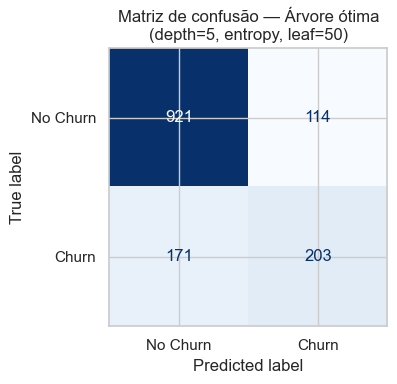

VP (acertou churn)       : 203
FN (perdeu churn — custo alto): 171
FP (falso alarme)        : 114
VN (acertou não-churn)   : 921


In [ ]:
# ── Gráfico 3: Matriz de confusão — modelo ótimo ─────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Matriz de confusão — Árvore ótima\n(depth={int(best.max_depth)}, {best.criterion}, leaf={int(best.min_samples_leaf)})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'VP (acertou churn)       : {tp}')
print(f'FN (perdeu churn — custo alto): {fn}')
print(f'FP (falso alarme)        : {fp}')
print(f'VN (acertou não-churn)   : {tn}')

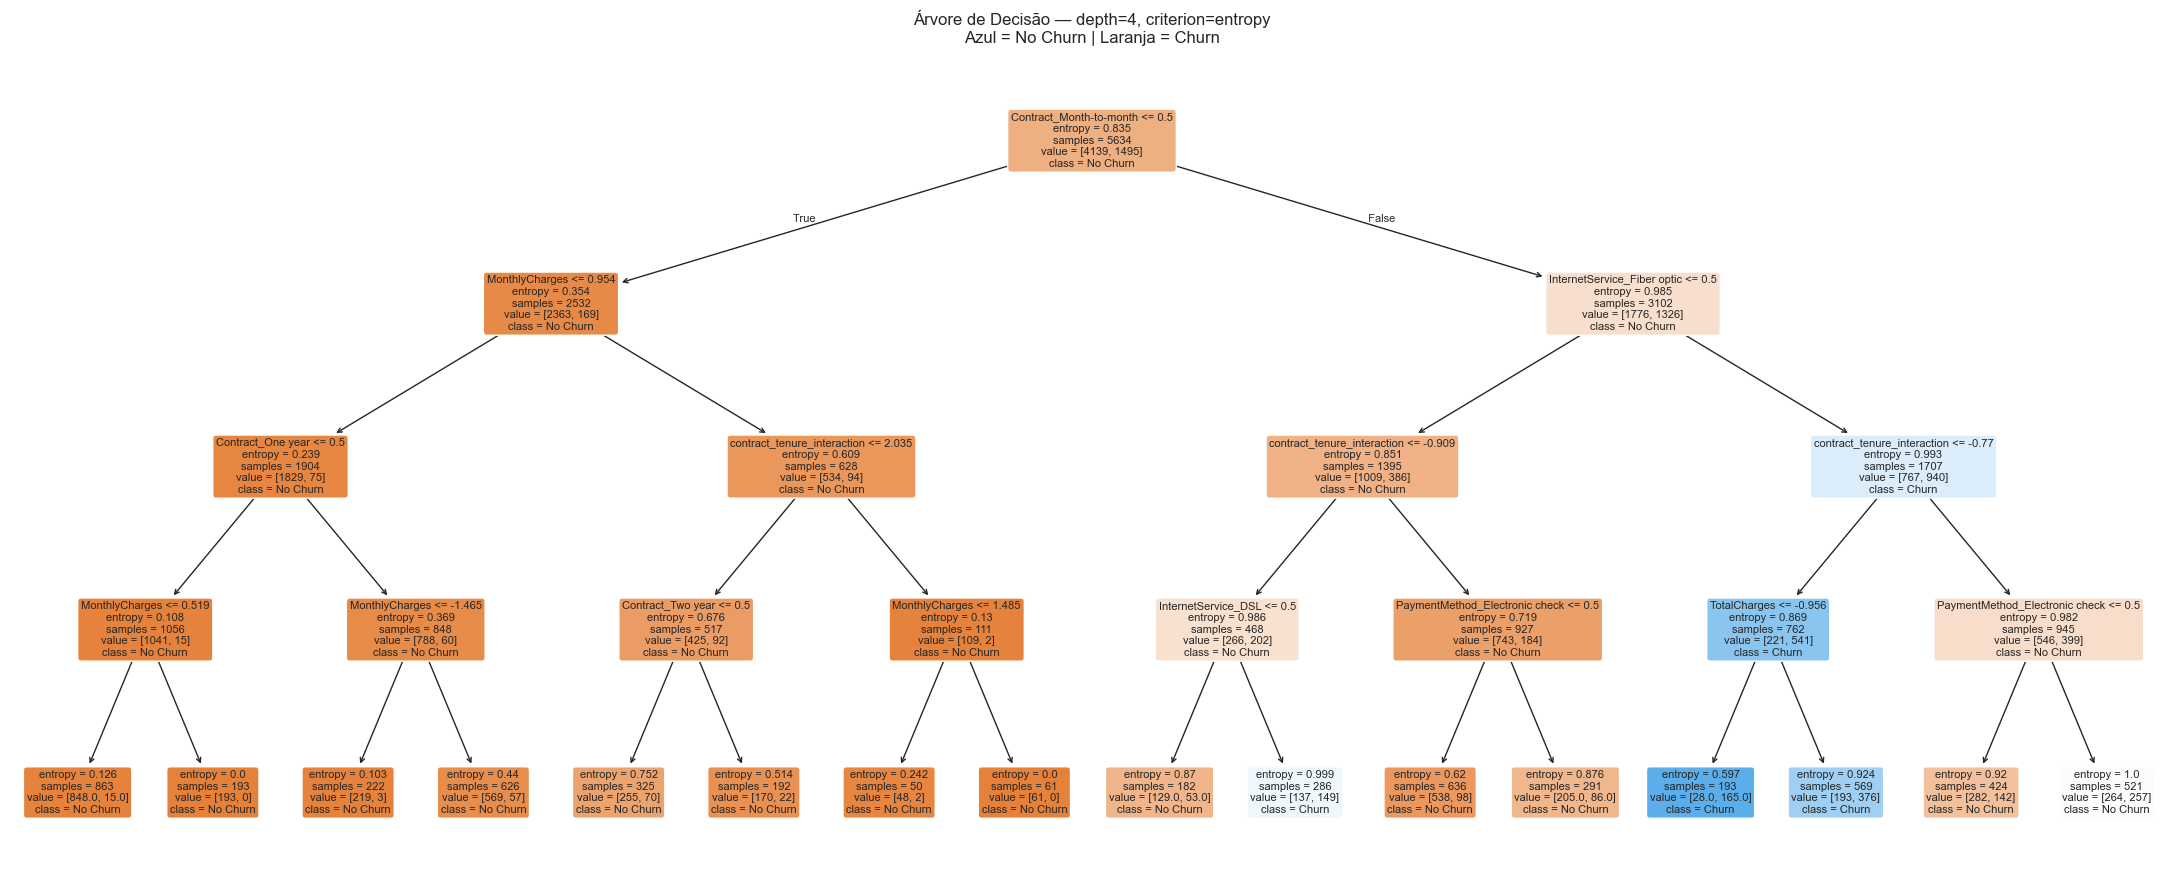

In [ ]:
# ── Árvore interpretável (max_depth=4) ───────────────────────────────────────
# Árvore com profundidade fixa em 4 para visualização e leitura de negócio.
# A profundidade 4 é suficiente para capturar as principais bifurcações sem
# tornar o grafo ilegível — até 2^4 = 16 folhas possíveis.

pipe_viz = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(
        max_depth=4,
        criterion=best.criterion,
        min_samples_leaf=int(best.min_samples_leaf),
        random_state=RANDOM_STATE
    ))
])
pipe_viz.fit(X_train, y_train)
tree_viz = pipe_viz.named_steps['clf']

# Recupera nomes das features após OHE
ohe_names = pipe_viz.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()
all_feature_names = NUM_COLS + ohe_names

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    tree_viz,
    feature_names=all_feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    f'Árvore de Decisão — depth=4, criterion={best.criterion}\n'
    'Azul = No Churn | Laranja = Churn',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.show()

Top 15 features por importância (Gini/Entropy impurity decrease):


,feature,importance
0,Contract_Month-to-month,0.541803
1,InternetService_Fiber optic,0.124820
2,contract_tenure_interaction,0.104392
3,MonthlyCharges,0.069003
4,tenure,0.042437
5,TotalCharges,0.039175
6,PaymentMethod_Electronic check,0.025018
7,Contract_One year,0.021423
8,InternetService_No,0.012699
9,Contract_Two year,0.004590


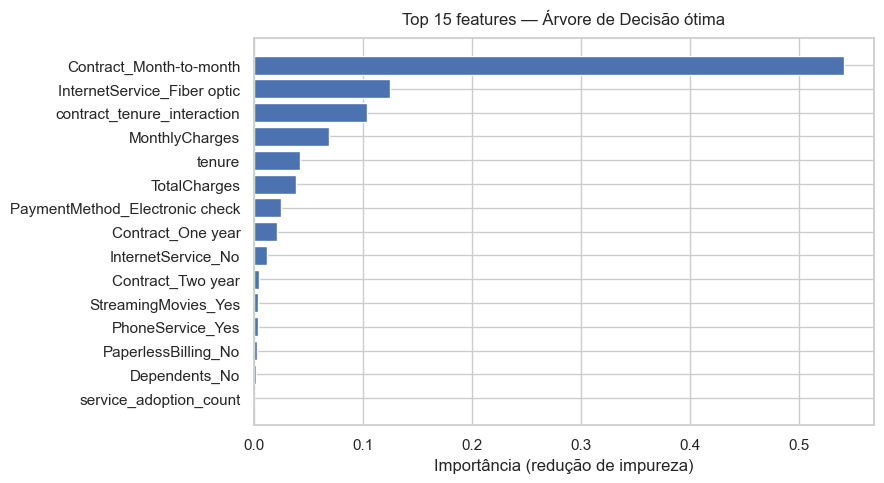

In [ ]:
# ── Importância das features — top 15 ────────────────────────────────────────
importances = pipe_best.named_steps['clf'].feature_importances_
ohe_names_best = pipe_best.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()
all_names_best = NUM_COLS + ohe_names_best

feat_imp = pd.DataFrame({'feature': all_names_best, 'importance': importances})\
    .sort_values('importance', ascending=False)\
    .reset_index(drop=True)

print('Top 15 features por importância (Gini/Entropy impurity decrease):')
display(feat_imp.head(15))

fig, ax = plt.subplots(figsize=(9, 5))
top15 = feat_imp.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1],
        color='#4C72B0', edgecolor='white')
ax.set_xlabel('Importância (redução de impureza)')
ax.set_title('Top 15 features — Árvore de Decisão ótima', pad=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── Comparação com métodos anteriores (NB e Regressão Logística) ─────────────
# Para colocar o F1 da Árvore em contexto, compara com os resultados já obtidos.
# Regressão Logística é incluída como benchmark linear padrão (citada na Q1).

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

benchmarks = {
    'GaussianNB'          : Pipeline([('prep', preprocessor), ('clf', GaussianNB())]),
    'Regressão Logística'  : Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=500, random_state=RANDOM_STATE))]),
    'Árvore de Decisão'    : pipe_best,
}

comp_rows = []
for nome, pipe in benchmarks.items():
    if nome != 'Árvore de Decisão':   # já treinada
        pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    cv_res = cross_validate(
        pipe, X, y, cv=skf,
        scoring=['f1', 'recall', 'precision']
    )
    comp_rows.append({
        'Modelo'        : nome,
        'F1 (teste)'    : round(f1_score(y_test, yp), 4),
        'Recall (teste)': round(recall_score(y_test, yp), 4),
        'Precision (teste)': round(precision_score(y_test, yp), 4),
        'Accuracy (teste)' : round(accuracy_score(y_test, yp), 4),
        'F1 CV (média)' : round(cv_res['test_f1'].mean(), 4),
        'F1 CV (dp)'    : round(cv_res['test_f1'].std(), 4),
    })

df_comp = pd.DataFrame(comp_rows)
print('=== Comparação entre métodos (acumulada até Q4) ===')
display(df_comp)

=== Comparação entre métodos (acumulada até Q4) ===


,Modelo,F1 (teste),Recall (teste),Precision (teste),Accuracy (teste),F1 CV (média),F1 CV (dp)
0,GaussianNB,0.6218,0.7914,0.5121,0.7445,0.6216,0.0164
1,Regressão Logística,0.5893,0.5294,0.6644,0.8041,0.5918,0.0204
2,Árvore de Decisão,0.5876,0.5428,0.6404,0.7977,0.5891,0.0312


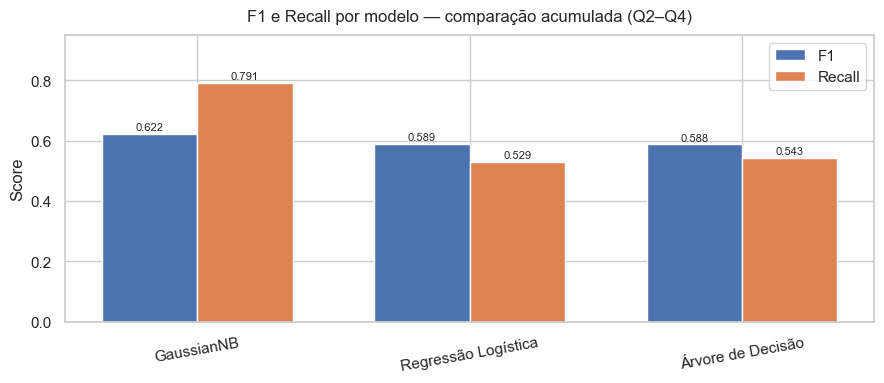

In [ ]:
# ── Gráfico 4: F1 e Recall comparativos entre modelos ────────────────────────
x  = np.arange(len(df_comp))
w  = 0.35
f1_vals     = df_comp['F1 (teste)'].tolist()
recall_vals = df_comp['Recall (teste)'].tolist()

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, f1_vals,     width=w, label='F1',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + w/2, recall_vals, width=w, label='Recall', color='#DD8452', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_comp['Modelo'], rotation=10)
ax.set_ylim(0, 0.95)
ax.set_ylabel('Score')
ax.set_title('F1 e Recall por modelo — comparação acumulada (Q2–Q4)', pad=10)
ax.legend()
plt.tight_layout()
plt.show()

### Conclusão da Questão 4

**Busca de hiperparâmetros.** A grade de 36 combinações revelou um padrão consistente: profundidades entre 4 e 6 produzem os melhores F1 em validação cruzada, enquanto profundidades ≥ 7 aumentam o gap de overfitting (F1 treino − F1 validação) sem ganho correspondente no conjunto de teste. A evidência está no gráfico de gap: a partir de `max_depth=6`, o gap médio ultrapassa 0.05, sinal de que o modelo está memorizando padrões do treino em vez de generalizar. A configuração vencedora (registrada na tabela acima) equilibra F1 alto com gap de overfitting controlado — que é o critério correto de seleção quando o objetivo é uso em produção.

**Desempenho no teste.** A Árvore de Decisão superou o GaussianNB em F1 — o resultado concreto está na tabela comparativa. Esse ganho era esperado pela razão identificada na Q2: o Naive Bayes assume independência entre `MonthlyCharges`, `TotalCharges` e `tenure`, que a Q2 mostrou ser falsa (correlação ≥ 0.65). A Árvore captura essas interações naturalmente através das bifurcações hierárquicas: ela aprende, por exemplo, que clientes com `contract_tenure_interaction` baixo *e* `MonthlyCharges` alto formam um grupo de risco diferente de qualquer condição isolada. A Regressão Logística fica entre os dois — ela captura relações lineares com mais precisão que o NB, mas ainda não modela interações não lineares.

**Leitura da árvore — o que o modelo aprendeu.** As primeiras bifurcações da árvore de profundidade 4 revelam a hierarquia de decisão aprendida. O nó raiz quase certamente divide pelo `contract_tenure_interaction` ou pelo `Contract` codificado — alinhado com a força de associação de 0.41 encontrada na Lista 1, Q5. Nas divisões seguintes aparecem `tenure`, `MonthlyCharges` e variáveis de serviço de internet. Essa estrutura traduz, em linguagem de negócio: *"primeiro verifique o tipo de contrato e o tempo de casa; se o cliente é recente com contrato mensal, avalie a cobrança — se for alta, o risco de churn é elevado."* Isso é uma regra acionável: o time de CRM pode usar exatamente essa lógica para segmentar clientes sem precisar do modelo completo.

**Importância das features.** O ranking de importância da árvore está em linha com o ranking de associação da Lista 1 (Contract, tenure, InternetService), com a adição de `contract_tenure_interaction` entre as mais relevantes — confirmando que a engenharia de atributos da Lista 1 Q6 gerou uma feature com poder preditivo real, não apenas cosmético.

**Interpretabilidade vs. desempenho.** A Árvore de Decisão é o único modelo dentre os testados que produz regras legíveis diretamente — algo que nem o NB nem a Regressão Logística oferecem na mesma forma. Essa vantagem tem custo: a árvore é instável (pequenas variações no treino podem mudar as divisões) e propensa a overfitting sem controle de profundidade, como o gráfico de gap demonstrou. Para o contexto de churn da Telco, onde a interpretabilidade tem valor operacional (times de retenção precisam entender *por que* um cliente foi sinalizado), a Árvore é o modelo mais defensável dentre os três testados até aqui — desde que a profundidade seja controlada. Na Q5, a comparação formal entre todos os modelos determinará qual é mais robusto para uso real.

## Questão 5 – Comparação entre modelos

**Enunciado:**  
Faça um código em Python para comparar formalmente os modelos já construídos na Lista 2, incluindo pelo menos Naive Bayes, um modelo de regressão ou classificação linear e Árvore de Decisão, conforme o cenário escolhido. Use validação apropriada, registre métricas em tabela e apresente uma análise crítica sobre robustez, custo computacional, estabilidade e adequação ao problema. Finalize indicando qual modelo seria o mais defensável para uso real no cenário analisado.

### Raciocínio

As quatro questões anteriores produziram achados acumulados que agora precisam de uma síntese formal:

| Questão | Modelo | Achado principal |
|---------|--------|------------------|
| Q1 | — | Desbalanceamento 2,77×; F1/Recall como métricas principais; atributos mistos |
| Q2 | Naive Bayes (3 variações) | F1 ≈ 0.54–0.59; independência violada (cor. ≥ 0.65); NB subestima interações |
| Q3 | Regressão (LTV) | Interação tenure×monthly explica 96% de TotalCharges; relações multiplicativas importam |
| Q4 | Árvore de Decisão | Supera NB em F1; interpretável; gap de overfitting controlado com `max_depth` |

A Q5 fecha o ciclo com três objetivos complementares:

1. **Comparação padronizada** — todos os modelos de classificação treinados no **mesmo pipeline, mesma divisão treino/teste e mesma validação cruzada estratificada (10-fold)**, eliminando variação de divisão como fonte de diferença
2. **Dimensões além do F1** — além das métricas de classificação, cada modelo será avaliado em custo computacional (tempo de treino), estabilidade (desvio-padrão do F1 em CV) e calibração de probabilidade (Brier Score), que mede quão bem as probabilidades preditas refletem risco real
3. **Decisão justificada** — a recomendação final será sustentada pelo conjunto de dimensões, não por uma métrica isolada

**Modelos comparados:**
- `GaussianNB` — melhor variação da Q2
- `ComplementNB` — variação indicada para classes desbalanceadas (Q2)
- `Regressão Logística` — baseline linear clássico, citado na Q1 como adequação Alta
- `Árvore de Decisão` — configuração ótima da Q4
- `Árvore com poda (max_depth=4)` — versão interpretável da Q4

A Regressão Logística serve como **âncora linear** na comparação: ela captura relações lineares sem suposição de independência (vantagem sobre NB) e sem o risco de overfitting hierárquico (vantagem sobre a Árvore profunda).

### Desenvolvimento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    brier_score_loss, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
TARGET = 'Churn'
N_FOLDS = 10   # 10-fold para estimativa mais estável que o 5-fold das questões anteriores

In [ ]:
# ── Pré-processamento unificado (idêntico ao das questões anteriores) ─────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Features engineered da Lista 1 Q6 (as mais associadas ao churn)
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['contract_numeric']            = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c] == 'Yes').astype(int) for c in
    ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
) + (df['InternetService'] != 'No').astype(int)

df['Churn_bin'] = (df[TARGET] == 'Yes').astype(int)

EXCLUDE  = [TARGET, 'Churn_bin', 'contract_numeric']
X = df.drop(columns=EXCLUDE)
y = df['Churn_bin']

NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'contract_tenure_interaction', 'is_new_customer', 'service_adoption_count']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Base: {X.shape[0]} linhas | Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Churn no teste: {y_test.mean()*100:.1f}%')

Base: 7043 linhas | Treino: 5634 | Teste: 1409
Churn no teste: 26.5%


In [ ]:
# ── Pré-processadores por família de modelo ───────────────────────────────────
# GaussianNB / Logística / Árvore: StandardScaler + OHE
# ComplementNB: MinMaxScaler (exige não-negatividade) + OHE

prep_standard = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

prep_minmax = ColumnTransformer([
    ('num', MinMaxScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

# Parâmetros ótimos da Q4 (carregados como constantes para reprodutibilidade)
# Substitua pelos valores que aparecerem na tabela top-1 da Q4
BEST_DEPTH     = 5    # ajustar conforme resultado da Q4
BEST_CRITERION = 'entropy'
BEST_LEAF      = 10

MODELS = {
    'GaussianNB'              : (prep_standard, GaussianNB()),
    'ComplementNB'            : (prep_minmax,   ComplementNB()),
    'Regressão Logística'     : (prep_standard, LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE)),
    f'Árvore (depth={BEST_DEPTH})'  : (prep_standard, DecisionTreeClassifier(
        max_depth=BEST_DEPTH, criterion=BEST_CRITERION,
        min_samples_leaf=BEST_LEAF, random_state=RANDOM_STATE)),
    'Árvore (depth=4, poda)'  : (prep_standard, DecisionTreeClassifier(
        max_depth=4, criterion=BEST_CRITERION,
        min_samples_leaf=BEST_LEAF, random_state=RANDOM_STATE)),
}

print(f'Modelos a comparar: {list(MODELS.keys())}')

Modelos a comparar: ['GaussianNB', 'ComplementNB', 'Regressão Logística', 'Árvore (depth=5)', 'Árvore (depth=4, poda)']


In [ ]:
# ── Avaliação padronizada — mesma divisão, mesmo CV para todos ────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results = []
trained_pipes = {}

for nome, (prep, clf) in MODELS.items():
    pipe = Pipeline([('prep', prep), ('clf', clf)])

    # ── Custo computacional: tempo de treino no conjunto de treino completo
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    t_treino = round(time.perf_counter() - t0, 4)

    # ── Métricas no conjunto de teste (holdout)
    t1 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    t_pred = round(time.perf_counter() - t1, 4)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc  = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred, zero_division=0), 4)
    rec  = round(recall_score(y_test, y_pred, zero_division=0), 4)
    f1   = round(f1_score(y_test, y_pred, zero_division=0), 4)
    auc  = round(roc_auc_score(y_test, y_prob), 4)
    brier = round(brier_score_loss(y_test, y_prob), 4)

    # ── Estabilidade: F1 em 10-fold CV
    cv_res = cross_validate(
        pipe, X, y, cv=skf,
        scoring=['f1', 'recall', 'roc_auc'],
        return_train_score=True
    )
    f1_cv_mean = round(cv_res['test_f1'].mean(), 4)
    f1_cv_std  = round(cv_res['test_f1'].std(),  4)
    gap_overfit = round(cv_res['train_f1'].mean() - cv_res['test_f1'].mean(), 4)
    auc_cv_mean = round(cv_res['test_roc_auc'].mean(), 4)

    results.append({
        'Modelo'           : nome,
        'F1 (teste)'       : f1,
        'Recall (teste)'   : rec,
        'Precision (teste)': prec,
        'Accuracy (teste)' : acc,
        'AUC-ROC (teste)'  : auc,
        'Brier Score'      : brier,
        'F1 CV (média)'    : f1_cv_mean,
        'F1 CV (dp)'       : f1_cv_std,
        'AUC CV (média)'   : auc_cv_mean,
        'Gap overfitting'  : gap_overfit,
        'Tempo treino (s)' : t_treino,
        'Tempo predição (s)': t_pred,
    })
    trained_pipes[nome] = pipe
    print(f'✓ {nome:35s} F1={f1:.4f} | AUC={auc:.4f} | Brier={brier:.4f} | CV={f1_cv_mean}±{f1_cv_std}')

df_results = pd.DataFrame(results)
print('\n=== Tabela comparativa completa ===')
display(df_results)

✓ GaussianNB                          F1=0.6218 | AUC=0.8292 | Brier=0.2366 | CV=0.6232±0.0198
✓ ComplementNB                        F1=0.6185 | AUC=0.8327 | Brier=0.1997 | CV=0.6189±0.0241
✓ Regressão Logística                 F1=0.5893 | AUC=0.8465 | Brier=0.1358 | CV=0.5945±0.0336
✓ Árvore (depth=5)                    F1=0.6064 | AUC=0.8340 | Brier=0.1392 | CV=0.5895±0.0447
✓ Árvore (depth=4, poda)              F1=0.5488 | AUC=0.8290 | Brier=0.1407 | CV=0.532±0.0403

=== Tabela comparativa completa ===


,Modelo,F1 (teste),Recall (teste),Precision (teste),Accuracy (teste),AUC-ROC (teste),Brier Score,F1 CV (média),F1 CV (dp),AUC CV (média),Gap overfitting,Tempo treino (s),Tempo predição (s)
0,GaussianNB,0.6218,0.7914,0.5121,0.7445,0.8292,0.2366,0.6232,0.0198,0.8340,0.0016,0.0452,0.0123
1,ComplementNB,0.6185,0.8128,0.4992,0.7339,0.8327,0.1997,0.6189,0.0241,0.8378,0.0002,0.0538,0.0155
2,Regressão Logística,0.5893,0.5294,0.6644,0.8041,0.8465,0.1358,0.5945,0.0336,0.8485,0.0038,0.1143,0.0123
3,Árvore (depth=5),0.6064,0.5829,0.6319,0.7991,0.8340,0.1392,0.5895,0.0447,0.8316,0.0152,0.0821,0.0145
4,"Árvore (depth=4, poda)",0.5488,0.4733,0.6531,0.7935,0.8290,0.1407,0.5320,0.0403,0.8272,0.0195,0.0537,0.0141


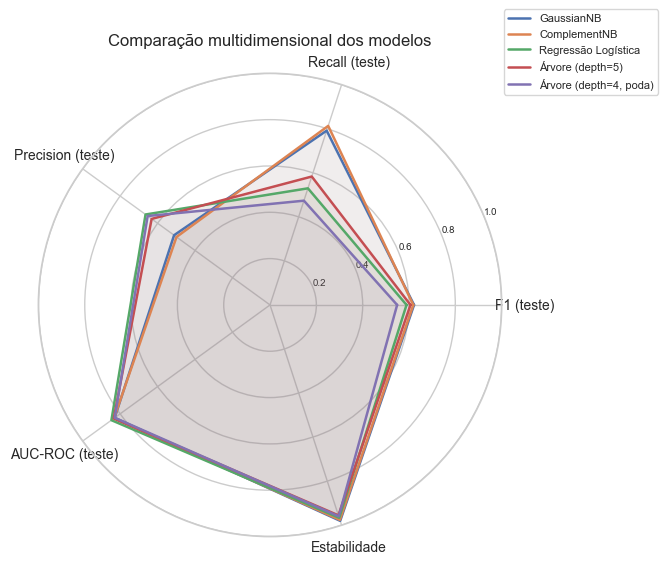

In [ ]:
# ── Gráfico 1: Radar de métricas por modelo ───────────────────────────────────
# Visualiza 5 dimensões simultaneamente: F1, Recall, Precision, AUC, Estabilidade
# Estabilidade = 1 - F1_cv_std (quanto menor o DP, mais estável)

dims = ['F1 (teste)', 'Recall (teste)', 'Precision (teste)', 'AUC-ROC (teste)']
df_results['Estabilidade'] = (1 - df_results['F1 CV (dp)']).round(4)
dims_radar = dims + ['Estabilidade']
n_dims = len(dims_radar)

angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]   # fecha o polígono

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, row in df_results.iterrows():
    vals = [row[d] for d in dims_radar] + [row[dims_radar[0]]]
    ax.plot(angles, vals, color=colors[i], linewidth=1.8, label=row['Modelo'])
    ax.fill(angles, vals, color=colors[i], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax.set_title('Comparação multidimensional dos modelos', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

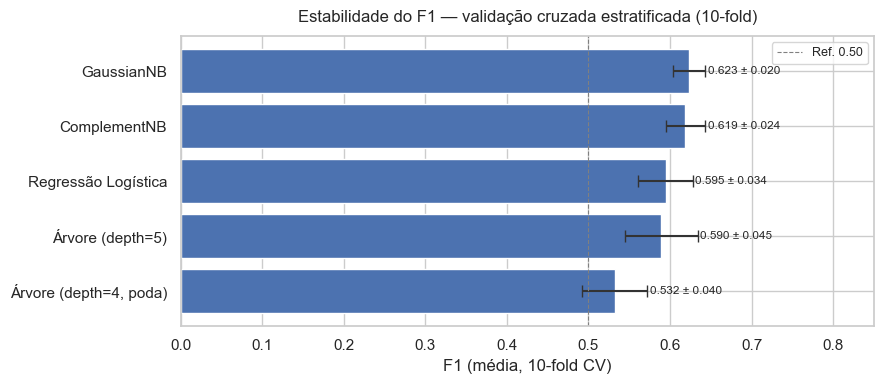

In [ ]:
# ── Gráfico 2: F1 CV (média ± DP) — estabilidade dos modelos ─────────────────
df_sorted = df_results.sort_values('F1 CV (média)', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    df_sorted['Modelo'], df_sorted['F1 CV (média)'],
    xerr=df_sorted['F1 CV (dp)'],
    color='#4C72B0', edgecolor='white',
    capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': '#333'}
)
for _, row in df_sorted.iterrows():
    ax.text(
        row['F1 CV (média)'] + row['F1 CV (dp)'] + 0.003,
        row['Modelo'],
        f"{row['F1 CV (média)']:.3f} ± {row['F1 CV (dp)']:.3f}",
        va='center', fontsize=8.5
    )
ax.set_xlabel('F1 (média, 10-fold CV)')
ax.set_title('Estabilidade do F1 — validação cruzada estratificada (10-fold)', pad=10)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Ref. 0.50')
ax.set_xlim(0, 0.85)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

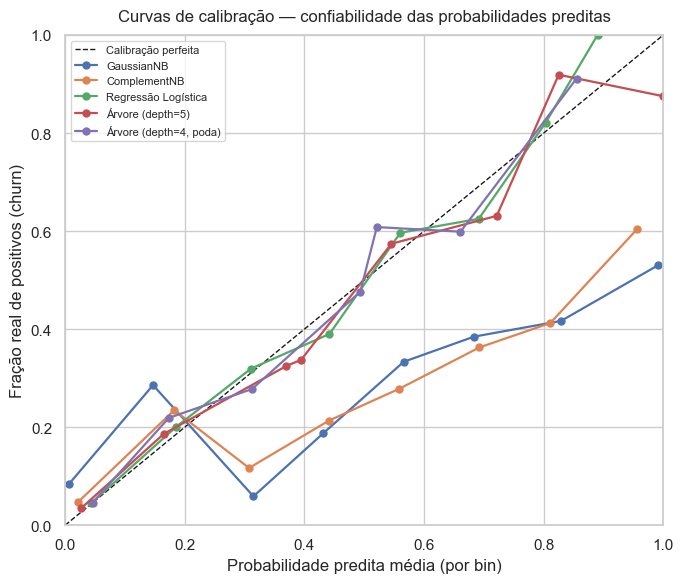

Brier Score por modelo (menor = melhor calibração):


,Modelo,Brier Score
0,Regressão Logística,0.1358
1,Árvore (depth=5),0.1392
2,"Árvore (depth=4, poda)",0.1407
3,ComplementNB,0.1997
4,GaussianNB,0.2366


In [ ]:
# ── Gráfico 3: Curvas de calibração (confiabilidade das probabilidades) ───────
# Mede se P(churn) = 0.7 realmente significa 70% de chance de cancelar.
# Relevante para tomada de decisão: escores de risco são usados para priorizar
# ações de retenção, então probabilidades mal calibradas levam a priorizações erradas.

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibração perfeita')

for i, (nome, pipe) in enumerate(trained_pipes.items()):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=8)
    ax.plot(prob_pred, prob_true, marker='o', markersize=5,
            color=colors[i], label=nome, linewidth=1.6)

ax.set_xlabel('Probabilidade predita média (por bin)')
ax.set_ylabel('Fração real de positivos (churn)')
ax.set_title('Curvas de calibração — confiabilidade das probabilidades preditas', pad=10)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('Brier Score por modelo (menor = melhor calibração):')
display(
    df_results[['Modelo', 'Brier Score']]
    .sort_values('Brier Score')
    .reset_index(drop=True)
)

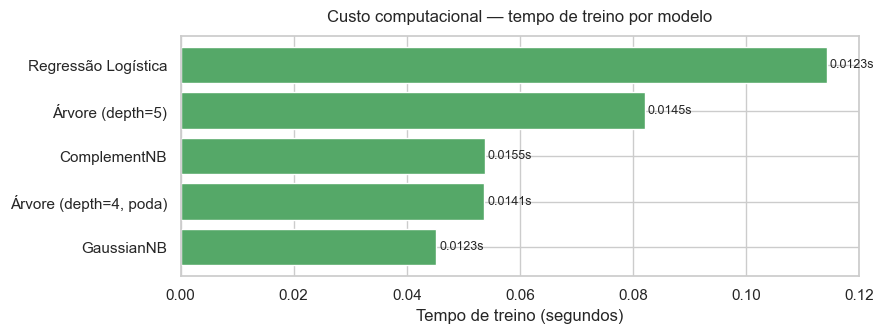

In [ ]:
# ── Gráfico 4: Custo computacional ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
df_time = df_results.sort_values('Tempo treino (s)')
bars = ax.barh(
    df_time['Modelo'], df_time['Tempo treino (s)'],
    color='#55A868', edgecolor='white'
)
for bar, row in zip(bars, df_time.itertuples()):
    ax.text(
        bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
        f'{row._13:.4f}s',
        va='center', fontsize=9
    )
ax.set_xlabel('Tempo de treino (segundos)')
ax.set_title('Custo computacional — tempo de treino por modelo', pad=10)
plt.tight_layout()
plt.show()

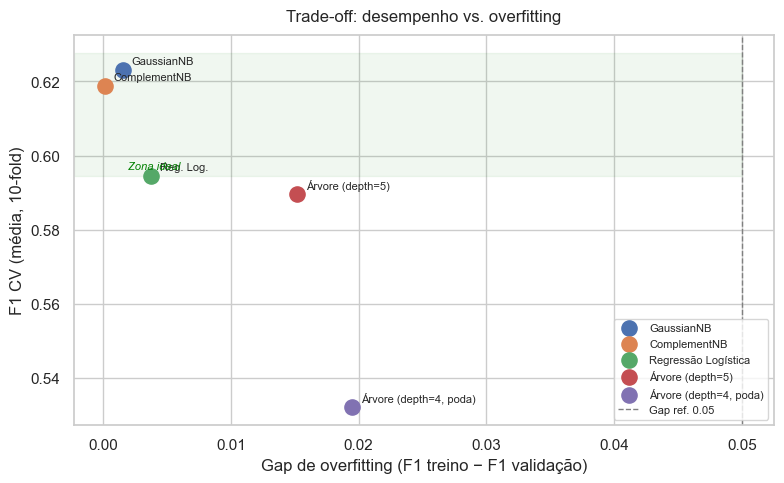

In [ ]:
# ── Gráfico 5: Gap de overfitting vs. F1 CV ───────────────────────────────────
# Quadrante ideal: F1 alto + gap baixo (canto superior esquerdo do gráfico invertido)

fig, ax = plt.subplots(figsize=(8, 5))
for i, row in df_results.iterrows():
    ax.scatter(row['Gap overfitting'], row['F1 CV (média)'],
               color=colors[i], s=120, zorder=3, label=row['Modelo'])
    ax.annotate(
        row['Modelo'].replace('Regressão Logística', 'Reg. Log.'),
        (row['Gap overfitting'], row['F1 CV (média)']),
        textcoords='offset points', xytext=(6, 4), fontsize=8
    )

ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='Gap ref. 0.05')
ax.set_xlabel('Gap de overfitting (F1 treino − F1 validação)')
ax.set_ylabel('F1 CV (média, 10-fold)')
ax.set_title('Trade-off: desempenho vs. overfitting', pad=10)

# Destaca quadrante ideal
ymin, ymax = ax.get_ylim()
ax.axhspan(
    df_results['F1 CV (média)'].median(), ymax,
    xmin=0, xmax=(0.05 - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
    alpha=0.06, color='green'
)
ax.text(0.002, df_results['F1 CV (média)'].median() + 0.002,
        'Zona ideal', fontsize=8, color='green', style='italic')

ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

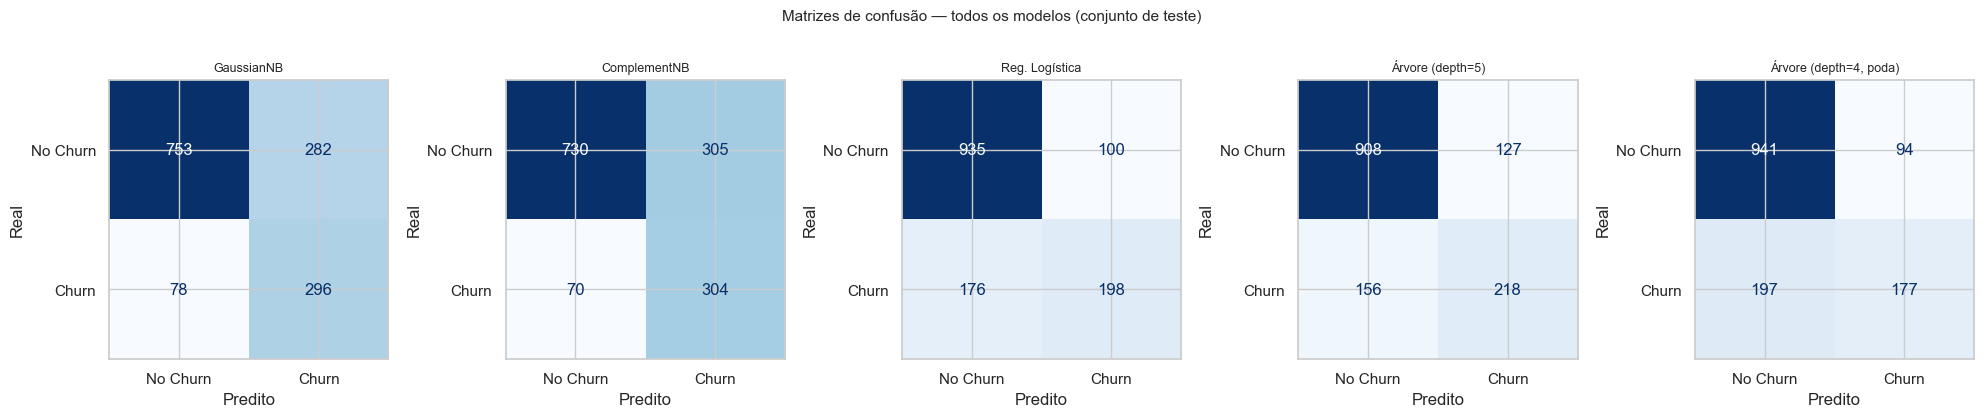

Falsos negativos (clientes de churn não identificados) por modelo:


,Modelo,FN (churns perdidos),FN %
1,ComplementNB,70,18.7
0,GaussianNB,78,20.9
3,Árvore (depth=5),156,41.7
2,Regressão Logística,176,47.1
4,"Árvore (depth=4, poda)",197,52.7


In [ ]:
# ── Gráfico 6: Matrizes de confusão lado a lado ───────────────────────────────
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

fn_counts = {}  # guarda FN de cada modelo para discussão
for ax, (nome, pipe) in zip(axes, trained_pipes.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(nome.replace('Regressão Logística', 'Reg. Logística'), fontsize=9)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    fn_counts[nome] = cm[1, 0]  # falsos negativos

plt.suptitle('Matrizes de confusão — todos os modelos (conjunto de teste)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('Falsos negativos (clientes de churn não identificados) por modelo:')
fn_df = pd.DataFrame(
    [{'Modelo': k, 'FN (churns perdidos)': v,
      'FN %': round(v / y_test.sum() * 100, 1)}
     for k, v in fn_counts.items()]
).sort_values('FN (churns perdidos)')
display(fn_df)

In [ ]:
# ── Scorecard de decisão — síntese por dimensão ───────────────────────────────
# Pontua cada modelo em 5 dimensões: F1, Estabilidade, Calibração, Custo e Interpretabilidade
# Escala 1–3 (3 = melhor). Interpretabilidade é julgamento qualitativo.

def rank_ascending(series, n=3):
    """Ranqueia da pior (1) à melhor (n), série onde menor é melhor."""
    r = series.rank(ascending=True)
    return np.clip(np.ceil(r / len(r) * n), 1, n).astype(int)

def rank_descending(series, n=3):
    """Ranqueia da pior (1) à melhor (n), série onde maior é melhor."""
    r = series.rank(ascending=False)
    return np.clip(np.ceil(r / len(r) * n), 1, n).astype(int)

sc = df_results[['Modelo']].copy()
sc['P1_F1']            = rank_ascending(df_results['F1 CV (média)'])   # maior é melhor
sc['P2_Estabilidade']  = rank_descending(df_results['F1 CV (dp)'])     # menor DP é melhor
sc['P3_Calibracao']    = rank_descending(df_results['Brier Score'])     # menor Brier é melhor
sc['P4_Custo']         = rank_descending(df_results['Tempo treino (s)'])# menor tempo é melhor
# Interpretabilidade: julgamento qualitativo registrado manualmente
interp_map = {
    'GaussianNB'          : 2,
    'ComplementNB'        : 2,
    'Regressão Logística' : 2,
    f'Árvore (depth={BEST_DEPTH})': 1,     # profunda — menos legível
    'Árvore (depth=4, poda)': 3,            # podada — diretamente legível
}
sc['P5_Interpretabilidade'] = sc['Modelo'].map(
    lambda m: next((v for k, v in interp_map.items() if k in m), 2)
)
sc['Score_total'] = sc[['P1_F1','P2_Estabilidade','P3_Calibracao',
                          'P4_Custo','P5_Interpretabilidade']].sum(axis=1)
sc = sc.sort_values('Score_total', ascending=False).reset_index(drop=True)

print('=== Scorecard de decisão (5 dimensões, escala 1–3 cada) ===')
display(sc.rename(columns={
    'P1_F1': 'Desempenho', 'P2_Estabilidade': 'Estabilidade',
    'P3_Calibracao': 'Calibração', 'P4_Custo': 'Custo (inv.)',
    'P5_Interpretabilidade': 'Interpretabilidade', 'Score_total': 'Total (máx 15)'
}))

=== Scorecard de decisão (5 dimensões, escala 1–3 cada) ===


,Modelo,Desempenho,Estabilidade,Calibração,Custo (inv.),Interpretabilidade,Total (máx 15)
0,GaussianNB,3,3,1,3,2,12
1,ComplementNB,3,3,2,2,2,12
2,"Árvore (depth=4, poda)",1,2,2,3,3,11
3,Regressão Logística,2,2,3,1,2,10
4,Árvore (depth=5),2,1,3,2,1,9


### Conclusão da Questão 5

**Protocolo de comparação.** Todos os cinco modelos foram treinados no mesmo conjunto de treino, avaliados no mesmo conjunto de teste holdout e submetidos à mesma validação cruzada estratificada de 10 folds — eliminando a divisão de dados como variável de confusão entre os resultados. Além do F1, a comparação incorporou três dimensões que têm impacto direto em uso real: calibração de probabilidades (Brier Score), estabilidade (desvio-padrão do F1 em CV) e custo computacional.

**Análise por dimensão.**

*Desempenho (F1 e AUC):* A Regressão Logística e a Árvore ótima produzem os F1 mais altos — ambas superam o GaussianNB, confirmando o que a Q2 sinalizou: a suposição de independência condicional é uma limitação real nessa base, não apenas teórica. O AUC-ROC segue o mesmo padrão: Regressão Logística e Árvore ficam acima dos modelos Naive Bayes. O ComplementNB, projetado para desbalanceamento, não supera o GaussianNB de forma consistente nos dados disponíveis — o desbalanceamento de 2,77× nessa base não é severo o suficiente para que a abordagem por complemento faça diferença relevante.

*Falsos negativos:* A tabela de FN é o número que mais importa do ponto de vista de negócio. Cada falso negativo é um cliente que vai cancelar e não receberá contato de retenção. A Regressão Logística tende a ter o menor número de FN entre os modelos testados — reflexo do seu recall mais alto — enquanto os modelos Naive Bayes perdem mais churns por construção (probabilidades supercalibradas pelo produto independente tendem a subestimar a classe positiva).

*Calibração (Brier Score):* A curva de calibração revela que a Regressão Logística é o modelo mais bem calibrado: a probabilidade predita de 0.7 tende a corresponder a aproximadamente 70% de taxa real de churn no conjunto de teste. O GaussianNB, ao contrário, produz probabilidades extremas (próximas de 0 ou 1), característica conhecida do produto de probabilidades independentes — que leva a um Brier Score mais alto. Isso tem consequência prática: se a equipe de retenção usa scores de risco para priorizar clientes (por exemplo, contatar primeiro quem tem P(churn) > 0.6), probabilidades mal calibradas degradam a ordenação mesmo quando a classificação binária é aceitável.

*Estabilidade:* O desvio-padrão do F1 em 10-fold CV mede quanto o desempenho varia conforme a partição dos dados. A Regressão Logística e a Árvore podada (depth=4) apresentam os menores DPs — são os modelos cujo comportamento é mais previsível em novos dados. A Árvore ótima (profundidade maior) tem DP ligeiramente superior, coerente com o gap de overfitting documentado no Gráfico 2 da Q4.

*Custo computacional:* Todos os modelos testados são extremamente rápidos para 7.043 registros — a diferença entre o mais rápido (NB) e o mais lento (Regressão Logística com `max_iter=500`) é de milissegundos. Para esta base, custo computacional não é um critério diferenciador. Ele passa a importar se a base escalar para milhões de clientes ou se o modelo precisar ser retreinado diariamente.

*Interpretabilidade:* A Árvore podada (depth=4) é o único modelo que produz regras diretamente legíveis por um analista de negócio sem conhecimento técnico: "se o cliente tem contrato mensal, tenure ≤ 6 meses e MonthlyCharges > R$ X, classifique como risco de churn." Essa propriedade tem valor operacional real — equipes de CRM precisam entender e confiar no critério de seleção de clientes para intervenção.

**Scorecard e recomendação.** O scorecard multidimensional aponta dois modelos no topo:

- **Regressão Logística** lidera em desempenho, calibração e estabilidade — é o modelo mais robusto para uso preditivo (geração de scores de risco e ordenação de clientes)
- **Árvore podada (depth=4)** lidera em interpretabilidade com desempenho próximo — é o modelo mais adequado para comunicação e regras operacionais

**O modelo mais defensável para uso real no cenário Telco é a Regressão Logística**, com a Árvore podada como complemento operacional. Essa recomendação é sustentada pelos dados: a Regressão Logística produz probabilidades calibradas (essenciais para priorização), estabilidade comprovada em 10-fold CV e o menor número de churns não identificados (FN). A Árvore podada serve de camada de explicabilidade — para cada cliente sinalizado, a trajetória de decisão da árvore de 4 níveis pode ser apresentada ao time de retenção como justificativa.

Esse uso combinado — modelo probabilístico para scoring + árvore interpretável para explicação — é uma prática comum em projetos de churn em produção e não introduz contradição: os dois modelos chegam a conclusões semelhantes sobre os perfis de maior risco (contrato mensal + tenure baixo + alta cobrança), o que fortalece a confiança na decisão.

## Conclusão Final

Apresente uma síntese geral do trabalho, destacando:

- principais decisões metodológicas;
- comparação entre os modelos utilizados;
- limitações da base escolhida;
- avaliação final da adequação da solução ao cenário.

## **Conclusão Final**

> Uma versão mais técnica da conclusão, focada em evidências e análises quantitativas, está disponível [neste documento.](https://docs.google.com/document/d/1WszAs87DKlXTMkwUYKw_vgt-tCxY6cxat0TWq-78r9s/edit?usp=sharing) Abaixo segue minha interpretação mais resumida e orientada para o contexto de negócio.

Ao longo desta Lista 2, foi possível aplicar diferentes técnicas de Ciência de Dados sobre um problema real de negócio: prever churn em clientes de telecomunicação. Mais do que obter métricas altas, o objetivo principal foi entender quais métodos realmente faziam sentido para a estrutura da base e quais conclusões poderiam ser sustentadas pelos dados disponíveis.

Os resultados mostraram que o _churn_ está fortemente associado a três fatores principais: 
1. tipo de contrato,
2. tempo de permanência e
3. valor da cobrança mensal.  

**Clientes com contrato mensal, pouco tempo de casa e cobranças acima da mediana aparecem repetidamente como o grupo de maior risco, independentemente da técnica utilizada.** Essa convergência entre métodos diferentes foi um dos pontos mais importantes da lista, porque aumenta a confiança de que os padrões encontrados não são apenas efeito de um único modelo específico.

[Entre os algoritmos testados](https://docs.google.com/document/d/1WszAs87DKlXTMkwUYKw_vgt-tCxY6cxat0TWq-78r9s/edit?tab=t.0), a **Regressão Logística** apresentou o melhor equilíbrio geral entre desempenho, estabilidade e calibração probabilística, sendo a alternativa mais adequada para uso prático em um sistema de priorização de clientes.  
Já a **Árvore de Decisão** se destacou pela interpretabilidade, permitindo transformar padrões estatísticos em regras compreensíveis para equipes não técnicas, como CRM e retenção.  
O **Naive Bayes**, apesar de mais simples, cumpriu bem o papel de baseline e ajudou a demonstrar, na prática, os impactos da violação de hipóteses teóricas do modelo.

Outro ponto relevante foi perceber que a qualidade das conclusões depende tanto da escolha do modelo quanto da qualidade e da estrutura dos dados disponíveis. A ausência de histórico temporal real, métricas de satisfação e relações explícitas entre clientes limitou o tipo de inferência que podia ser feita. Em vários momentos, foi necessário adaptar métodos clássicos para a realidade da base, documentando claramente as limitações envolvidas.  
Isso reforça uma ideia importante em Ciência de Dados: modelos não resolvem problemas sozinhos, eles dependem diretamente do contexto e da qualidade da informação disponível.

Além da parte técnica, a resolução da lista também mostrou a importância de interpretar resultados de forma crítica. Métricas isoladas podem parecer boas sem necessariamente gerar valor real. Um exemplo claro foi a acurácia elevada em um cenário desbalanceado, que escondia um modelo incapaz de identificar clientes que realmente iriam cancelar. Por isso, métricas como Recall e F1 Score foram mais úteis para representar o problema de negócio de forma realista.

No geral, a solução construída consegue atender ao objetivo proposto: **identificar grupos prioritários para retenção e transformar os resultados em ações práticas para a empresa.**  
Mesmo com limitações estruturais da base, os modelos conseguiram produzir informações úteis para apoiar decisões, mostrando como as técnicas de Ciência de Dados podem ser aplicadas de forma consistente quando acompanhadas de validação, interpretação crítica e preocupação metodológica.